## 0. Imports and Definitions

In [1]:
# Umap of Latent space

In [2]:
import socket

print(socket.gethostname())
assert "login" not in socket.gethostname()

gpu25.cluster.embl.de


In [3]:
import os
import random
import shap
import copy

from sklearn.metrics import roc_curve, auc

os.environ["JAX_ENABLE_X64"] = "False"
os.environ["TF_GPU_ALLOCATOR"] = "cuda_malloc_async"

import jax

jax.config.update("jax_disable_jit", True)
jax.config.update("jax_enable_x64", False)

import scanpy as sc
import mofaflex as mfl
import scvi
from drvi.model import DRVI
from tqdm import tqdm
from IPython.display import display, Markdown
from sklearn.cluster import KMeans
from scipy.spatial.distance import pdist, squareform

from functools import partial

import decoupler as dc
from pydeseq2.dds import DeseqDataSet, DefaultInference
from pydeseq2.ds import DeseqStats

import anndata as ad
from mudata import MuData
import pertpy as pt

from scib_metrics.benchmark import Benchmarker, BioConservation, BatchCorrection
from sklearn.decomposition import PCA
from scipy.stats import spearmanr

import numpy as np
from seaborn import clustermap
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from types import SimpleNamespace

from src.utils.utils import (
    compute_counterfactual_distances,
    compute_nearest_neighbor_distances,
    compute_latent_effect,
    compute_correlations,
    reverse_dict,
    display_csv,
    compute_neighbors,
    augment_with_noise,
    filter_xdata,
    load_scvi,
    check_adata_params,
)
from src.utils.zinb import inferr_zinb_params

from src.analysis.plotting import (
    plot_MPMI,
    plot_ME_spectrum,
    plot_loss,
    plot_umap,
    plot_hist,
    compare_spectra,
    compare_latent_effects,
    plot_correlation_distribution,
    plot_PCA_spectrum,
)
from src.analysis.me_metrics import get_jacobian, get_MPMI, get_manifold_entropy
from src.analysis.analysis_utils import (
    Analyzer,
    get_losses_ablation,
    analyze_model,
    analyze_result,
    return_bottleneck_representation,
    test_latent_shape,
    get_model_from_checkpoint,
    calculate_pca,
    compare_pca,
    check_analyzer_params,
)
from src.analysis.logistic_regression import (
    LogisticRegressionClassifier,
    train_classifier,
)
from src.analysis.factor_analysis import (
    plot_factors_for_covariate,
    pca_get_gene_importances,
    pca_plot_factors_grid,
)
from src.analysis.enrichment_analysis import (
    bulk_enrichment_analysis,
    evaluate_gene_contribution,
    compare_intra_gene_contributions,
    compare_inter_gene_contributions,
)
from src.analysis.pertubation_effects import (
    evaluate_de_effects,
    evaluate_de_effects_gt,
    _get_gt_sig_genes,
    evaluate_permuted_results,
    LearnedSoftPermutation,
    LearnedDimSelector,
    _get_logfold_changes,
    _collect_lfc_results,
    differentiable_lfc_results,
    decay_loss,
)
from src.analysis.cluster_analysis import (
    plot_latent_means_umap,
    plot_pairwise_distances,
    plot_encoded_means_pca,
)

from src.model.data_utils import (
    load_data,
    prepare_data,
    get_condition_shapes,
    prepare_train_test_data,
    create_latent_adata,
    build_metacells,
    AdataDataset,
)
from src.model.training import train_model
from src.model.build_model import get_model, remap_keys, init_config
from src.model.config import INNConfig

import plotly.graph_objects as go

import gc
import warnings
import socket
import torch
from torch.utils.data import DataLoader

assert "login" not in socket.gethostname()

warnings.filterwarnings("ignore", category=FutureWarning)

Importing the dtw module. When using in academic works please cite:
  T. Giorgino. Computing and Visualizing Dynamic Time Warping Alignments in R: The dtw Package.
  J. Stat. Soft., doi:10.18637/jss.v031.i07.



In [4]:
device = "cuda" if torch.cuda.is_available() else "cpu"
dtype = torch.float32
adata = None
analyzer = None

## 1. Loading and Preprocessing

In [5]:
dataset_args = {
    "dataset_name": "parse",
    "top_genes": 2000,
    "sigma_noise": 4,
    "batch_size": 512,
}

In [6]:
USE_METACELLS = False
DONOR = ["Donor1"]

In [7]:
if not USE_METACELLS:
    adata, labels_key, control_label = load_data(
        dataset_args["dataset_name"],
        dataset_args["top_genes"],
        log_transform=True,
        cell_types=["CD4 Memory"],
    )
else:
    adata, labels_key, control_label = load_data(
        dataset_args["dataset_name"],
        dataset_args["top_genes"],
        log_transform=True,
        cell_types=None,
        donors=DONOR,
    )
    print(adata.X.shape)
    adata = build_metacells(adata, group_keys=["cell_type", f"{labels_key}"])

mdata = MuData({"rna": adata})
dataset_args["top_genes"] = min(adata.shape[1], dataset_args["top_genes"])

In [8]:
print(adata.X.shape)
print(adata.obs[f"{labels_key}"].value_counts())
print(adata.obs[f"cell_type"].value_counts())

# ALL DONORS:
# full adata.X: (1703041, 2000)
# Metacells: adata.X: (84758, 2000)

(76265, 1779)
cytokine
PBS            26545
IL-4            8141
CT-1            7302
IL-1-beta       6872
IL-2            5270
IFN-epsilon     4878
CD27L           4710
FGF-beta        3862
IL-32-beta      3586
IL-13           2960
CD40L           2139
Name: count, dtype: int64
cell_type
CD4 Memory    76265
Name: count, dtype: int64


## 1. Toy Datasets

### 1.1 Gaussian Data

In [ ]:
def create_gaussian(n_samples, n_dim):

    mean = np.zeros(n_dim, dtype=np.float32)
    cov = np.zeros((n_dim, n_dim), dtype=np.float32)

    return np.random.multivariate_normal(mean, cov, size=n_samples).astype(np.float32)

In [ ]:
gaussian_data = create_gaussian(n_samples=adata.shape[0], n_dim=adata.shape[1])
adata.X = gaussian_data

### 1.2 Multimodal Gaussian

In [ ]:
def create_multimodal_gaussian(
    n_samples,
    n_dim,
    n_modes,
):

    rng = np.random.default_rng(4)

    # distribute samples approximately evenly
    samples_per_mode = [n_samples // n_modes] * n_modes
    for i in range(n_samples % n_modes):
        samples_per_mode[i] += 1

    data = []
    labels = []

    for mode_idx, n_mode_samples in enumerate(samples_per_mode):

        mean = rng.random(n_dim) * np.sqrt(n_dim) * 5
        cov = np.eye(n_dim) / n_dim

        mode_data = rng.multivariate_normal(mean, cov, size=n_mode_samples).astype(
            np.float32
        )

        data.append(mode_data)

        labels.extend([mode_idx] * n_mode_samples)

    X = np.vstack(data)
    labels = np.array(labels)

    # shuffle samples
    permutation = rng.permutation(n_samples)
    X = X[permutation]
    labels = labels[permutation]

    # create obs dataframe
    labels_key = "cluster"
    control_label = None
    obs = pd.DataFrame(
        {
            f"{labels_key}": pd.Categorical(labels.astype(str)),
            "cell_type": pd.Categorical(["neuron"] * n_samples),
        }
    )

    # optional variable names
    var = pd.DataFrame(index=[f"feature_{i}" for i in range(n_dim)])

    # create AnnData object
    adata = ad.AnnData(
        X=X,
        obs=obs,
        var=var,
    )
    adata.layers["counts"] = adata.X.copy()

    return adata, labels_key, control_label

In [ ]:
dataset_args = {
    "dataset_name": "gauss",
    "top_genes": 2000,
    "sigma_noise": 4,
    "batch_size": 512,
}

dim = 1800
adata, labels_key, control_label = create_multimodal_gaussian(
    n_samples=20000,
    n_dim=dim,
    n_modes=11,
)
dataset_args["top_genes"] = dim

In [ ]:
plt.plot(adata.X[:, 0], adata.X[:, 1], ".", alpha=0.5, markersize=2)

In [ ]:
sc.pp.neighbors(adata)
sc.tl.umap(adata)
sc.pl.umap(adata, color=[f"{labels_key}", "cell_type"])

## 2. Visualize

### 2.1 ZINB

In [ ]:
inferr_zinb_params(adata, gene=119)

### 2.2 UMAP

In [ ]:
adata.X

In [ ]:
sc.pp.pca(adata)
sc.pp.neighbors(adata)
sc.tl.umap(adata)

sc.pl.umap(adata, color=["cell_type", "cytokine"])

## 3. E-Distance and E-Test

In [ ]:
distance = pt.tl.Distance("edistance")
groupby = f"{labels_key}" if not USE_METACELLS else "product"
sc.pp.pca(adata)

adata.obs["product"] = (
    adata.obs[["cell_type", labels_key]].astype(str).agg("__".join, axis=1)
)

# df_condition = distance.pairwise(adata, groupby=f"{labels_key}")
df = distance.pairwise(adata, groupby="product")

In [ ]:
df.head()

In [ ]:
# clustermap(df_cell_type, robust=True, figsize=(5, 5))
# plt.show()

postfix = "metacells" if USE_METACELLS else ""
clustermap(df, robust=True, figsize=(5, 5))
plt.savefig(f"e_dist_{postfix}")
plt.show()

In [ ]:
etest = pt.tl.DistanceTest("edistance", obsm_key="X_pca", n_perms=500, alpha=0.0015)
tab = etest(adata, groupby="condition", contrast="ctrl")

In [ ]:
tab.head()

In [ ]:
with sns.axes_style("darkgrid"):
    sns.scatterplot(
        data=tab[tab.index != "ctrl"],
        x="pvalue",
        y="distance",
        hue="significant",
        palette={True: "green", False: "red"},
    )
plt.title("E-test results")
plt.xlabel("E-test p-value")
plt.ylabel("E-distance to contrast group (control)")
plt.show()

## 4. DE Analysis

In [ ]:
sc.tl.rank_genes_groups(adata, groupby="condition", method="wilcoxon")
sc.pl.rank_genes_groups(adata)
sc.pl.rank_genes_groups_dotplot(
    adata, groupby="condition", standard_scale="var", n_genes=20
)

In [ ]:
sc.tl.rank_genes_groups(adata, groupby="cell_type", method="wilcoxon")
sc.pl.rank_genes_groups(adata)
sc.pl.rank_genes_groups_dotplot(
    adata, groupby="cell_type", standard_scale="var", n_genes=10
)

## 5. MOFAFlex

In [ ]:
mofa_path = os.path.join(
    "./models",
    "mofa",
    dataset_args["dataset_name"]
    + "_"
    + str(dataset_args["top_genes"])
    + "_mofa_checkpoint.h5",
)
checkpoint_exists = os.path.exists(mofa_path)

if checkpoint_exists:
    mofa_model = mfl.MOFAFLEX.load(mofa_path)
else:
    mofa_model = mfl.MOFAFLEX(
        mdata,
        mfl.ModelOptions(n_factors=15),
        mfl.TrainingOptions(batch_size=1000, save_path=mofa_path, max_epochs=1000),
    )

In [ ]:
mfl.pl.training_curve(mofa_model)

In [ ]:
mfl.pl.factor_correlation(mofa_model)

In [ ]:
mfl.pl.variance_explained(mofa_model)

In [ ]:
mfl.pl.top_weights(mofa_model, figsize=(10, 10), n_features=100)

In [ ]:
Z_mofa = mofa_model.get_factors()["group_1"]
adata.obsm["X_mofa"] = Z_mofa

In [ ]:
sc.pl.umap(adata, color="cell_type", basis="X_mofa")

## 6. scVI

### 6.1 Model Loading

In [ ]:
model_name = (
    dataset_args["dataset_name"] + "_" + str(dataset_args["top_genes"]) + "_model.pt"
)
print(model_name)

In [ ]:
model_dir = os.path.join("models", "scvi_model")
model_dir_unsupervised = os.path.join("models", "scvi_model_unsupervised")

checkpoint_exists = os.path.exists(os.path.join(model_dir, model_name))
checkpoint_exists_unsupervised = os.path.exists(
    os.path.join(model_dir_unsupervised, model_name)
)
print(os.path.join(model_dir_unsupervised, model_name))
print(checkpoint_exists_unsupervised)

In [ ]:
if not checkpoint_exists:
    scvi.model.SCVI.setup_anndata(
        adata, layer="counts", categorical_covariate_keys=[f"{labels_key}", "cell_type"]
    )
    scvi_model = scvi.model.SCVI(adata)
    scvi_model.train(train_size=0.8, check_val_every_n_epoch=5, early_stopping=True)
    scvi_model.save(
        model_dir, overwrite=True, anndata_write_kwargs={"filename": model_name}
    )
else:
    scvi_model = scvi.model.SCVI.load(
        model_dir,
        adata=adata,
        prefix=dataset_args["dataset_name"]
        + "_"
        + str(dataset_args["top_genes"])
        + "_",
    )

In [ ]:
if not checkpoint_exists_unsupervised:
    scvi.model.SCVI.setup_anndata(adata, layer="counts")
    scvi_model_unsupervised = scvi.model.SCVI(adata)
    scvi_model_unsupervised.train(
        train_size=0.8, check_val_every_n_epoch=5, early_stopping=True
    )
    scvi_model_unsupervised.save(
        model_dir_unsupervised,
        overwrite=True,
        anndata_write_kwargs={"filename": model_name},
    )
else:
    scvi_model_unsupervised = scvi.model.SCVI.load(
        model_dir_unsupervised,
        adata=adata,
        prefix=dataset_args["dataset_name"]
        + "_"
        + str(dataset_args["top_genes"])
        + "_",
    )

In [ ]:
SCVI_LATENT_KEY = "X_scVI"

Z_scvi = scvi_model.get_latent_representation()
adata.obsm[SCVI_LATENT_KEY] = Z_scvi

SCVI_LATENT_KEY_UNSUPERVISED = "X_scVI_un"

Z_scvi_unsupervised = scvi_model_unsupervised.get_latent_representation()
adata.obsm[SCVI_LATENT_KEY_UNSUPERVISED] = Z_scvi_unsupervised

### 6.2 Evaluation

In [ ]:
hist = scvi_model.history


def plot_metric(train_key, val_key, title, ylabel):
    plt.figure(figsize=(6, 4))
    plt.plot(hist[train_key], label="train")
    plt.plot(hist[val_key], label="validation")
    plt.xlabel("Epoch")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [ ]:
# Negative ELBO (Evidence lower bound)
if "elbo_train" in hist:
    plot_metric("elbo_train", "elbo_validation", "ELBO", "ELBO")

In [ ]:
# Reconstruction loss
plot_metric(
    "reconstruction_loss_train",
    "reconstruction_loss_validation",
    "Reconstruction loss",
    "Negative log likelihood",
)

In [ ]:
reps = ["X_scVI_un", "X_scVI"]
titles = ["scVI un", "X_scVI"]

colors = [f"{labels_key}", "cell_type"]

fig, axes = plt.subplots(2, 2, figsize=(16, 14))
for i, rep in enumerate(reps):
    sc.pp.neighbors(adata, use_rep=rep)
    sc.tl.umap(adata)

    for j, color in enumerate(colors):
        sc.pl.umap(
            adata,
            color=color,
            ax=axes[i, j],
            show=False,
            title=f"{titles[i]} - {color}",
        )

plt.tight_layout()
plt.show()

## 7. ConstrativeVI

In [ ]:
adata

In [ ]:
model_dir = os.path.join("models", "contrastiveVI_model")
model_name = (
    dataset_args["dataset_name"] + "_" + str(dataset_args["top_genes"]) + "_model.pt"
)

In [ ]:
if not os.path.exists(os.path.join(model_dir, model_name)):
    scvi.external.ContrastiveVI.setup_anndata(adata, layer="counts")
    contrastive_vi_model = scvi.external.ContrastiveVI(
        adata, n_salient_latent=10, n_background_latent=10, use_observed_lib_size=False
    )
    background_indices = np.where(adata.obs["condition"] == "ctrl")[0]
    target_indices = np.where(adata.obs["condition"] != "ctrl")[0]
    contrastive_vi_model.train(
        background_indices=background_indices,
        target_indices=target_indices,
        early_stopping=True,
        max_epochs=500,
    )
    contrastive_vi_model.save(
        model_dir, overwrite=True, anndata_write_kwargs={"filename": model_name}
    )
else:
    contrastive_vi_model = scvi.external.ContrastiveVI.load(
        model_dir, adata=adata, prefix=dataset + "_"
    )

In [ ]:
perturbed_adata = adata[adata.obs["condition"] != "ctrl"]
perturbed_adata.obsm["salient_rep"] = contrastive_vi_model.get_latent_representation(
    perturbed_adata, representation_kind="salient"
)

sc.pp.neighbors(perturbed_adata)
sc.tl.umap(perturbed_adata)
sc.pl.umap(perturbed_adata, color=["cell_type", "condition"])

In [ ]:
sc.pp.neighbors(perturbed_adata, use_rep="salient_rep")
sc.tl.umap(perturbed_adata)
sc.pl.umap(perturbed_adata, color=["phase", "gene_program"])

## 8. DRVI

In [ ]:
DRVI.setup_anndata(
    adata,
    layer="counts",
    batch_key="condition",
    # In addition to batch_key, you can also provide additional `categorical_covariate_keys`.
    # DRVI accepts count data by default.
    # Set to false if you provide log-normalized data and use normal distribution (mse loss).
    is_count_data=True,
)

## 9. EOFlow

### 9.1 Nearest Neighbor Statistic

In [ ]:
nearest_distances_log = []
nearest_distances_orig = []

for i in range(10):
    neighbors_log = compute_nearest_neighbor_distances(adata.X, device=device, k=i + 1)
    nearest_distances_log.append(neighbors_log[:, -1].cpu().numpy())
    neighbors_orig = compute_nearest_neighbor_distances(
        adata.layers["counts"], device=device, k=i + 1
    )
    nearest_distances_orig.append(neighbors_orig[:, -1].cpu().numpy())
nearest_distances_log = np.array(nearest_distances_log)
nearest_distances_orig = np.array(nearest_distances_orig)

mean_nn_dist_log = nearest_distances_log.mean(axis=1).mean()
mean_nn_dist_orig = nearest_distances_orig.mean(axis=1).mean()
print("Mean nearest neighbor distance (log-normalized data):", mean_nn_dist_log)
print("Mean nearest neighbor distance (original counts):", mean_nn_dist_orig)

In [ ]:
fig, ax = plt.subplots(2, 1, figsize=(10, 12))
for i in range(10):
    ax[0].hist(nearest_distances_log[i], bins=50, alpha=0.5, label=f"{i+1}th neighbor")
    ax[1].hist(
        nearest_distances_orig[i],
        bins=150,
        alpha=0.5,
        label=f"{i+1}th neighbor",
        range=(0, 150),
    )
ax[0].set_title(f"Hist of distances to k nearest neighbors in log space")
ax[1].set_title(f"Hist of distances to k nearest neighbors in original space")
ax[0].set_xlabel("Distance")
ax[1].set_xlabel("Distance")
ax[0].set_ylabel("Frequency")
ax[1].set_ylabel("Frequency")
ax[0].legend()
ax[1].legend()
ax[0].grid(True)
ax[1].grid(True)
plt.show()

In [ ]:
noise = 40 / np.sqrt(1691)
print(noise)

### 9.2 Model Setup

In [ ]:
dataset_args["sigma_noise"] = 0.1
dataset_args["lam_MTC"] = 0.3
dataset_args["use_counts"] = False
dataset_args["batch_size"] = 1024
prefix = "4_8_"

In [12]:
conditions = [f"{labels_key}"]
condition_shapes = None
condition_type = None
if conditions is not None:
    condition_shapes = get_condition_shapes(adata, conditions)
    condition_type = "mixture"
    trainable_means = True
    trainable_simga = True
print("Condition shapes:", condition_shapes)

Condition shapes: [11]


In [13]:
supervise_latent_meaning = "partition"
lam_supervise = 0.01

In [14]:
test_size = 0.0

dataset, dataloader, test_dataset, test_dataloader = prepare_train_test_data(
    adata,
    dataset_args["batch_size"],
    device,
    dtype,
    counts=dataset_args["use_counts"],
    label_key=conditions,
    test_size=test_size,
)
D_dim = dataset.X.shape[1]
N_dim = D_dim

In [15]:
for x, c in dataloader:
    print("Batch shape:", x.shape)
    print(x[:, 11:].shape)
    print("Condition shape:", c[0].shape)
    break

Batch shape: torch.Size([1024, 1779])
torch.Size([1024, 1768])
Condition shape: torch.Size([1024, 11])


In [16]:
dataset_name = dataset_args["dataset_name"]
top_genes = min(dataset_args["top_genes"], D_dim)
sigma_noise = dataset_args["sigma_noise"]
lam_MTC = dataset_args["lam_MTC"]

model_path = os.path.join(
    "/g/stegle/jhoefer/models/EOFlow", dataset_name, "top_" + str(top_genes)
)
model_name = prefix + "MTC_" + str(lam_MTC) + "_sigma_" + str(sigma_noise) + "_model.pt"

output_dir_path = os.path.join(
    "/home/jhoefer/sandbox/results", dataset_name, "top_" + str(top_genes)
)
output_dir_name = prefix + "MTC_" + str(lam_MTC) + "_sigma_" + str(sigma_noise)

if dataset_args["use_counts"]:
    model_path += "_counts"
    output_dir_path += "_counts"

model_path += "_best"
output_dir_path += "_best"
print(f"Model path: {model_path}")
print(f"Model name: {model_name}")

plot_dir = os.path.join(output_dir_path, "plots", output_dir_name)
log_dir = os.path.join(output_dir_path, "logs", output_dir_name)
csv_dir = os.path.join(output_dir_path, "csv", output_dir_name)
os.makedirs(plot_dir, exist_ok=True)
os.makedirs(log_dir, exist_ok=True)
os.makedirs(csv_dir, exist_ok=True)

checkpoint_path = os.path.join(model_path, model_name)

Model path: /g/stegle/jhoefer/models/EOFlow/parse/top_1779_best
Model name: 3_5_MTC_0.3_sigma_0.1_model.pt


In [17]:
kwargs_data = {
    "device": device,
    "dtype": dtype,
    "N_dim": N_dim,
    "D_dim": D_dim,
    "dataset": dataset,
    "train_dataloader": dataloader,
    "test_dataloader": test_dataloader,
    "data_mean": dataset.X.mean(dim=0),
    "data_std": torch.ones(D_dim),
    "sigma_noise": sigma_noise,
    "sigma_inflate": sigma_noise,
}

kwargs_loss = {
    "use_NLL": True,
    "use_MER": True,
    "mode_MER": "unbiased",  #'full', #'unbiased'
    "lam_MTC": lam_MTC,
    "lam_ME_i": list(np.zeros(D_dim)),
    # 'use_align': False,
    # 'dims_align': D_dim - 1,
    # 'lam_align': 1, #0.1,
    # 'lam_disent': 0, #0.1,
    "use_rec": False,
    "dims_rec": D_dim - 1,
    "lam_rec": 100,  #
    "sigma_noise": sigma_noise,
}

metrics_loss = {
    "epoch": [],
    "loss": [],
    "z2": [],
    "NLL": [],
    "MTC": [],
    "H_i": [],
    "H_core": [],
    "H_detail": [],
    "MI_core_detail": [],
    "L2_rec": [],
}
val_metrics_loss = metrics_loss.copy()

In [18]:
model_config = INNConfig(
    N_dim=N_dim,
    N_blocks=8,
    condition_shapes=condition_shapes,
    pre_normalize=False,
    normalize=True,
    warmup_steps=2 * len(dataloader),
    condition_type=condition_type,
    trainable_means=trainable_means,
    n_clusters=len(dataset.cats[0].categories),
    lr_means=5e-3,
    supervise_latent_meaning=supervise_latent_meaning,
    ctrl_idx=dataset.cats[0].categories.tolist().index(control_label),
    lam_supervise=lam_supervise,
    trainable_sigma=trainable_simga,
    latent_per_condition=8,
)

In [19]:
flow, optimizer = get_model(model_config)

In [20]:
gc.collect()
torch.cuda.empty_cache()

### 9.3 Training

In [21]:
CONTINUE_TRAINING = True
NUM_EPOCHS = 1
# NUM_EPOCHS = int(NUM_EPOCHS * N_dim / dataset_args["batch_size"])
start_epoch = 0
log_path = None

In [22]:
print(os.path.join(model_path, model_name))

/g/stegle/jhoefer/models/EOFlow/parse/top_1779_best/3_5_MTC_0.3_sigma_0.1_model.pt


In [23]:
if os.path.exists(checkpoint_path):
    checkpoint = torch.load(
        checkpoint_path,
        map_location=device,
        weights_only=False,
    )

    metrics_loss = checkpoint["metrics_loss"]

    if "val_metrics_loss" in checkpoint:
        val_metrics_loss = checkpoint["val_metrics_loss"]

    log_path = checkpoint["log_path"]
    start_epoch = checkpoint["epoch"] + 1
    model_config = checkpoint["model_config"]

    model_config = init_config(model_config)

    print(f"Checkpoint found at epoch {checkpoint['epoch']}.")

    model, optimizer = get_model(model_config)

    model = model.to(device)
    saved_state = checkpoint["model_state_dict"]

    ## TODO: Remove fix
    # model.load_state_dict(checkpoint["model_state_dict"], strict=False)
    model = remap_keys(model, saved_state)
    
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])

    
else:
    print("No checkpoint found, starting training from scratch.")
    model, optimizer = get_model(model_config)
    model = model.to(device)

if CONTINUE_TRAINING:
    print(f"Starting training from epoch {start_epoch}...")

    model, optimizer, metrics_loss, val_metrics_loss, log_path = train_model(
        model,
        optimizer,
        metrics_loss,
        kwargs_data,
        kwargs_loss,
        save_model_path=checkpoint_path,
        model_config=model_config,
        val_metrics_loss=val_metrics_loss,
        num_epochs=NUM_EPOCHS,
        start_epoch=start_epoch,
        print_info=True,
        log_dir=log_dir,
        continue_log_path=log_path,
        conditions=conditions,
    )

Checkpoint found at epoch 1552.
Loaded successfully. Missing/fresh keys: []
Starting training from epoch 1553...
Sigma noise: 0.1


/home/jhoefer/sandbox/src/model/INN/INN_losses.py:37: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).


Average time per update: 0.7904 seconds


In [24]:
print(model_config.trainable_sigma)
print(model.log_sigma)
print(model.means_active.shape)

False
None
torch.Size([11, 55])


In [25]:
analyzer = Analyzer(
    adata,
    model,
    kwargs_data,
    labels_key,
    control_label,
    plot_dir,
    csv_dir,
    checkpoint_path,
    metrics_loss,
    conditions=conditions,
    condition_type=model_config.condition_type,
    val_metrics_loss=val_metrics_loss,
)

In [26]:
print(analyzer.condition_type)
print(analyzer.model.means.shape)
print(analyzer.plot_dir)

mixture
torch.Size([11, 1779])
/home/jhoefer/sandbox/results/parse/top_1779_best/plots/3_5_MTC_0.3_sigma_0.1


In [27]:
# test_latent_shape(analyzer, n_latent_factors=50, plot_dir=analyzer.plot_dir)

### 9.4 Bulk Enrichment Analysis

#### 9.5.0 Plots

In [ ]:
name = "P53_PATHWAY"
pert_hm_acts = {}

In [ ]:
adata.obs[f"{labels_key}"].value_counts()

In [ ]:
location = 0
IL2_analyzer = analyzer.subset(covariates=[f"{labels_key}"], keys=["IL-2"])

In [ ]:
bulk_enrichment_analysis(
    analyzer,
    location=None,
    use_noise=False,
    reorder=False,
)
bulk_enrichment_analysis(
    IL2_analyzer,
    location=0,
    use_noise=False,
    reorder=False,
)

#### 9.5.1 Consistency in one cluster

In [ ]:
length = 256
IL2_hm_acts_locations = []

for i in range(0, length, length // 10):
    hm_names, hm_acts = bulk_enrichment_analysis(
        IL2_analyzer,
        location=i,
        use_noise=False,
        return_results=True,
        reorder=False,
    )
    IL2_hm_acts_locations.append((i, hm_acts))
hm_names, hm_acts = bulk_enrichment_analysis(
    IL2_analyzer,
    location=None,
    use_noise=False,
    return_results=True,
    reorder=False,
)
IL2_hm_acts_locations.append(("mean", hm_acts))

In [ ]:
fig, axes = plt.subplots(
    len(IL2_hm_acts_locations),
    1,
    figsize=(12, len(IL2_hm_acts_locations) * 1.5),
    sharex=True,
)
indices = np.arange(len(IL2_hm_acts_locations[0][1]))

for (i, hm_acts), ax in zip(IL2_hm_acts_locations, axes):
    vals = hm_acts[:][name]
    ax.plot(indices, vals, linewidth=0.8)
    ax.fill_between(indices, vals, alpha=0.3)
    ax.set_ylabel(f"Loc {i}", rotation=0, labelpad=30)
    ax.set_yticks([])

plt.xlabel("Index")
plt.tight_layout()
plt.show()

#### 9.5.2 Consistency across clusters

In [ ]:
pertubations = adata.obs[f"{labels_key}"].unique()

for pert in pertubations:
    pert_analyzer = analyzer.subset(covariates=[f"{labels_key}"], keys=[pert])
    hm_names, hm_acts = bulk_enrichment_analysis(
        pert_analyzer,
        location=None,
        use_noise=False,
        return_results=True,
        reorder=False,
    )
    pert_hm_acts[pert] = hm_acts

In [ ]:
hm_names, hm_acts = bulk_enrichment_analysis(
    analyzer,
    location=None,
    use_noise=False,
    return_results=True,
    reorder=False,
)
pert_hm_acts["mean"] = hm_acts

In [ ]:
fig, axes = plt.subplots(
    len(pert_hm_acts), 1, figsize=(12, len(pert_hm_acts) * 1.5), sharex=True
)
indices = np.arange(len(list(pert_hm_acts.values())[0]))

for pert, ax in zip(pert_hm_acts.keys(), axes):
    vals = pert_hm_acts[pert][:][name]
    ax.plot(indices, vals, linewidth=0.8)
    ax.fill_between(indices, vals, alpha=0.3)
    ax.set_ylabel(f"{pert}", rotation=0, labelpad=30)
    ax.set_yticks([])

plt.xlabel("Index")
plt.tight_layout()
plt.show()

#### 9.5.3 Most important genes

In [ ]:
def get_outlier_indices_iqr(s, factor=5):
    Q1 = s.quantile(0.25)
    Q3 = s.quantile(0.75)
    IQR = Q3 - Q1
    return s[(s < Q1 - factor * IQR) | (s > Q3 + factor * IQR)].index


def test_overlap(analyzer, dim_idx, name, largest_k):
    hallmark = dc.op.hallmark(organism="human")
    sperm_genes = set(hallmark[hallmark["source"] == name]["target"].values)

    jac_col = analyzer.jac_dec[:, dim_idx].mean(0).cpu().numpy()
    top_genes = pd.Series(jac_col, index=analyzer.adata.var_names).nlargest(largest_k)

    overlap = set(top_genes.index) & sperm_genes
    print(f"Dominant gene in pathway? {overlap}")


def analyze_top_genes(analyzer, dim_idx, name, pos, top_k=20):

    jac_col = analyzer.jac_dec[:, dim_idx]  # (N_samples, N_genes)

    mean_importance = jac_col.mean(dim=0).cpu().numpy()  # average over samples
    std_importance = jac_col.std(dim=0).cpu().numpy()

    top_genes = pd.DataFrame(
        {
            "mean": mean_importance,
            "std": std_importance,
            "cv": std_importance / (np.abs(mean_importance) + 1e-8),
        },
        index=analyzer.adata.var_names,
    )

    print(f"\n=== dim_{dim_idx} | top {top_k} genes by |mean importance| ===")
    test_overlap(analyzer, dim_idx, name, largest_k=top_k)
    print(top_genes.reindex(top_genes["mean"].nlargest(top_k).index).to_string())

In [ ]:
outlier_idx = get_outlier_indices_iqr(hm_acts[:][name])
print(len(outlier_idx), "outlier dimensions:", outlier_idx.tolist())

positions = []
latent_sort = list(analyzer.latent_sort)
for idx in outlier_idx:
    idx = int(idx.replace("dim_", ""))
    pos = latent_sort.index(int(idx))
    positions.append(pos)
print("Positions of outlier dimensions in latent sort:", positions)

for pos, idx in zip(positions, outlier_idx):
    dim_idx = int(idx.replace("dim_", ""))
    analyze_top_genes(analyzer, dim_idx, name, pos, top_k=100)

check_dim = int(outlier_idx[0].split("_")[1])

In [ ]:
hallmark = dc.op.hallmark(organism="human")
androgen_genes = set(
    hallmark[hallmark["source"] == "ANDROGEN_RESPONSE"]["target"].values
)

jac_col = analyzer.jac_dec[:, check_dim].mean(0).cpu().numpy()
all_gene_scores = pd.Series(jac_col, index=analyzer.adata.var_names)

androgen_scores = all_gene_scores[all_gene_scores.index.isin(androgen_genes)]
print(f"N androgen genes found: {len(androgen_scores)}")
print(f"Mean score of androgen genes: {androgen_scores.mean():.4f}")
print(f"Mean score of all genes:      {all_gene_scores.mean():.4f}")
print(androgen_scores.sort_values(key=abs, ascending=False).head(20))

bg = all_gene_scores.values
pathway = androgen_scores.values

sns.kdeplot(bg, label="all genes")
sns.kdeplot(pathway, label="androgen")

plt.legend()
plt.show()

In [ ]:
z_all = []

dataset, dataloader = prepare_data(
    analyzer.adata,
    batchsize=1024,
    device=analyzer.device,
    dtype=analyzer.dtype,
    label_key=None,
    shuffle=False,
)

with torch.no_grad():

    for x_batch, _ in dataloader:
        x_batch = x_batch.to(
            device=analyzer.device,
            dtype=analyzer.dtype,
        )
        z_batch, _ = analyzer.model(
            x_batch,
            rev=False,
        )
        z_all.append(z_batch.cpu())

z_all = torch.cat(z_all, dim=0).numpy()
analyzer.adata.obs[f"z{check_dim}"] = z_all[:, int(check_dim)]

sc.pp.pca(adata)
sc.pp.neighbors(adata)
sc.tl.umap(adata)

sc.pl.umap(
    analyzer.adata,
    color=f"z{check_dim}",
    cmap="coolwarm",
)

In [ ]:
# similarities, gene_names_1, gene_names_2, latents_1, latents_2 = (
#     evaluate_gene_contribution(
#         adata,
#         IL2_analyzer,
#         gene_set=0,
#         top_latents=4,
#         top_genes=15,
#         location1=0,
#         location2=1,
#     )
# )

In [ ]:
# compare_intra_gene_contributions(gene_names_1, gene_names_2, latents_1, latents_2)

In [ ]:
# compare_inter_gene_contributions(gene_names_1, gene_names_2, latents_1, latents_2)

### 9.5 Factor Analysis

In [ ]:
top_k = 3
pca_top_genes = pca_get_gene_importances(analyzer, noise_level=0.4, top_k=top_k)
pca_plot_factors_grid(
    pca_top_genes,
    factor_indices=10,
    gene_names=analyzer.adata.var_names,
    top_k=top_k,
    n_cols=5,
)

In [ ]:
top_k = 15
cell_names = adata.obs["cell_type"].tolist()
IL4_analyzer = analyzer.subset(covariates=[f"{labels_key}"], keys=["IL-4"])

In [ ]:
plot_factors_for_covariate(
    analyzer,
    top_k=30,
    location=None,
    factor_indices=[545],
)

### 9.6 Distributions of Covariates

In [ ]:
def plot_covariate_distribution(analyzer, covariate, keys, n_dims=8, n_components=None):
    if analyzer.pca == None or analyzer.x_pca is None:
        analyzer.calculate_pca()

    fig, axes = plt.subplots(len(keys), n_dims, figsize=(n_dims * 4, len(keys) * 4))
    for j, key in enumerate(keys):
        mask = analyzer.adata.obs[covariate] == key
        for i in range(n_dims):
            axes[j, i].hist(
                analyzer.x_pca[mask, i],
                bins=30,
                alpha=0.5,
                label=f"{key} - dim {i}",
                density=True,
            )
            axes[j, i].hist(
                analyzer.x_pca[~mask, i],
                bins=30,
                alpha=0.5,
                label=f"Other - dim {i}",
                density=True,
            )
            axes[j, i].set_title(f"PCA Dim {i}")
            axes[j, i].legend()
    plt.tight_layout()
    plt.show()

In [ ]:
def plot_2d_covariate_distribution(
    analyzer, covariate, key, n_dims=5, n_components=None
):
    if analyzer.pca == None or analyzer.x_pca is None:
        analyzer.calculate_pca()

    mask = analyzer.adata.obs[covariate] == key

    # Build a DataFrame with the first n_dims PCA dimensions + group label
    df = pd.DataFrame(
        analyzer.x_pca[:, :n_dims], columns=[f"Dim {i}" for i in range(n_dims)]
    )
    df["group"] = np.where(mask, str(key), "Other")

    g = sns.PairGrid(df, hue="group", diag_sharey=False)
    g.map_diag(sns.kdeplot, fill=True, alpha=0.5)  # diagonal: 1D KDE
    g.map_offdiag(sns.kdeplot, fill=True, alpha=0.3)  # off-diagonal: 2D KDE
    g.add_legend()
    plt.show()

In [ ]:
plot_2d_covariate_distribution(analyzer, covariate=f"{labels_key}", key="IL-4")

In [ ]:
keys = adata.obs["cytokine"].value_counts().index.tolist()
plot_covariate_distribution(analyzer, covariate="cytokine", keys=keys)

### 9.6 Bottlenck UMAP


In [ ]:
gc.collect()
torch.cuda.empty_cache()

In [ ]:
z_latent, latent_sort = return_bottleneck_representation(
    analyzer,
    bottleneck_dim=int(top_genes),
)

In [ ]:
drop = 0

In [ ]:
adata.obsm["X_EOFlow"] = z_latent[:, latent_sort[100:]]
sc.pp.neighbors(adata, use_rep="X_EOFlow")
sc.tl.umap(adata)
sc.pl.umap(adata, color=["cell_type", f"{labels_key}"])

In [ ]:
latent_samples = np.random.randn(adata.X.shape[0], N_dim)
batch_size = 2048
samples = []
with torch.no_grad():
    for i in range(0, adata.X.shape[0], batch_size):
        batch = latent_samples[i : i + batch_size]
        batch = torch.tensor(batch, dtype=torch.float32, device=device)
        x_recon, _ = flow(batch, rev=True)
        samples.append(x_recon.cpu().numpy())
samples = np.concatenate(samples, axis=0)

adata.obsm["X_EOFlow_recon"] = samples
sc.pp.neighbors(adata, use_rep="X_EOFlow_recon")
sc.tl.umap(adata)
sc.pl.umap(adata, color=["cell_type", f"{labels_key}"])

### 9.7 Plots

In [29]:
gc.collect()
torch.cuda.empty_cache()

In [30]:
print(dataset_name)

parse


In [31]:
load_scvi(adata, dataset_name, N_dim)
analyzer.adata.obsm["X_scVI_un"] = adata.obsm["X_scVI_un"]

In [32]:
latent_dims = np.arange(10)

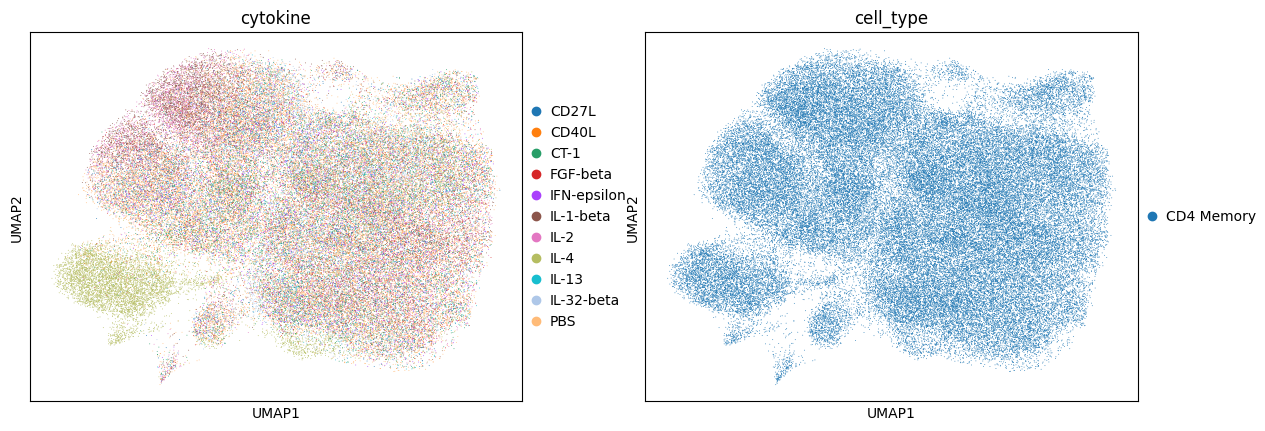

100%|████████████████████████████████████████████████████████████| 10/10 [00:33<00:00,  3.39s/it]


before forward: 2701.9 MiB
after forward: 2919.8 MiB
after grad: 6018.6 MiB


100%|██████████████████████████████████████████████████████| 1779/1779 [00:00<00:00, 8352.40it/s]


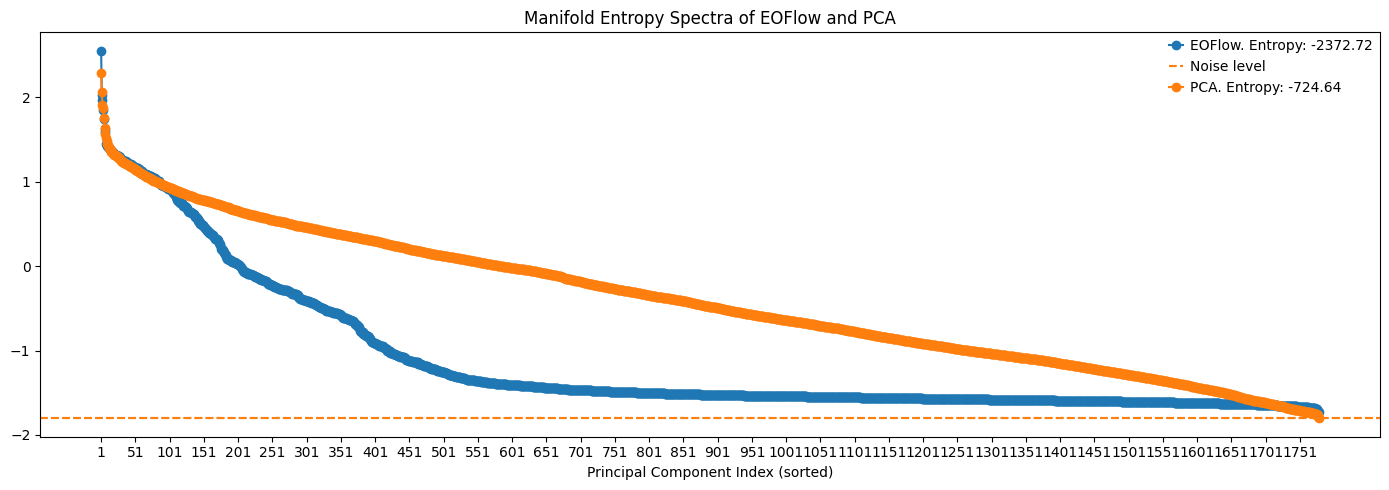

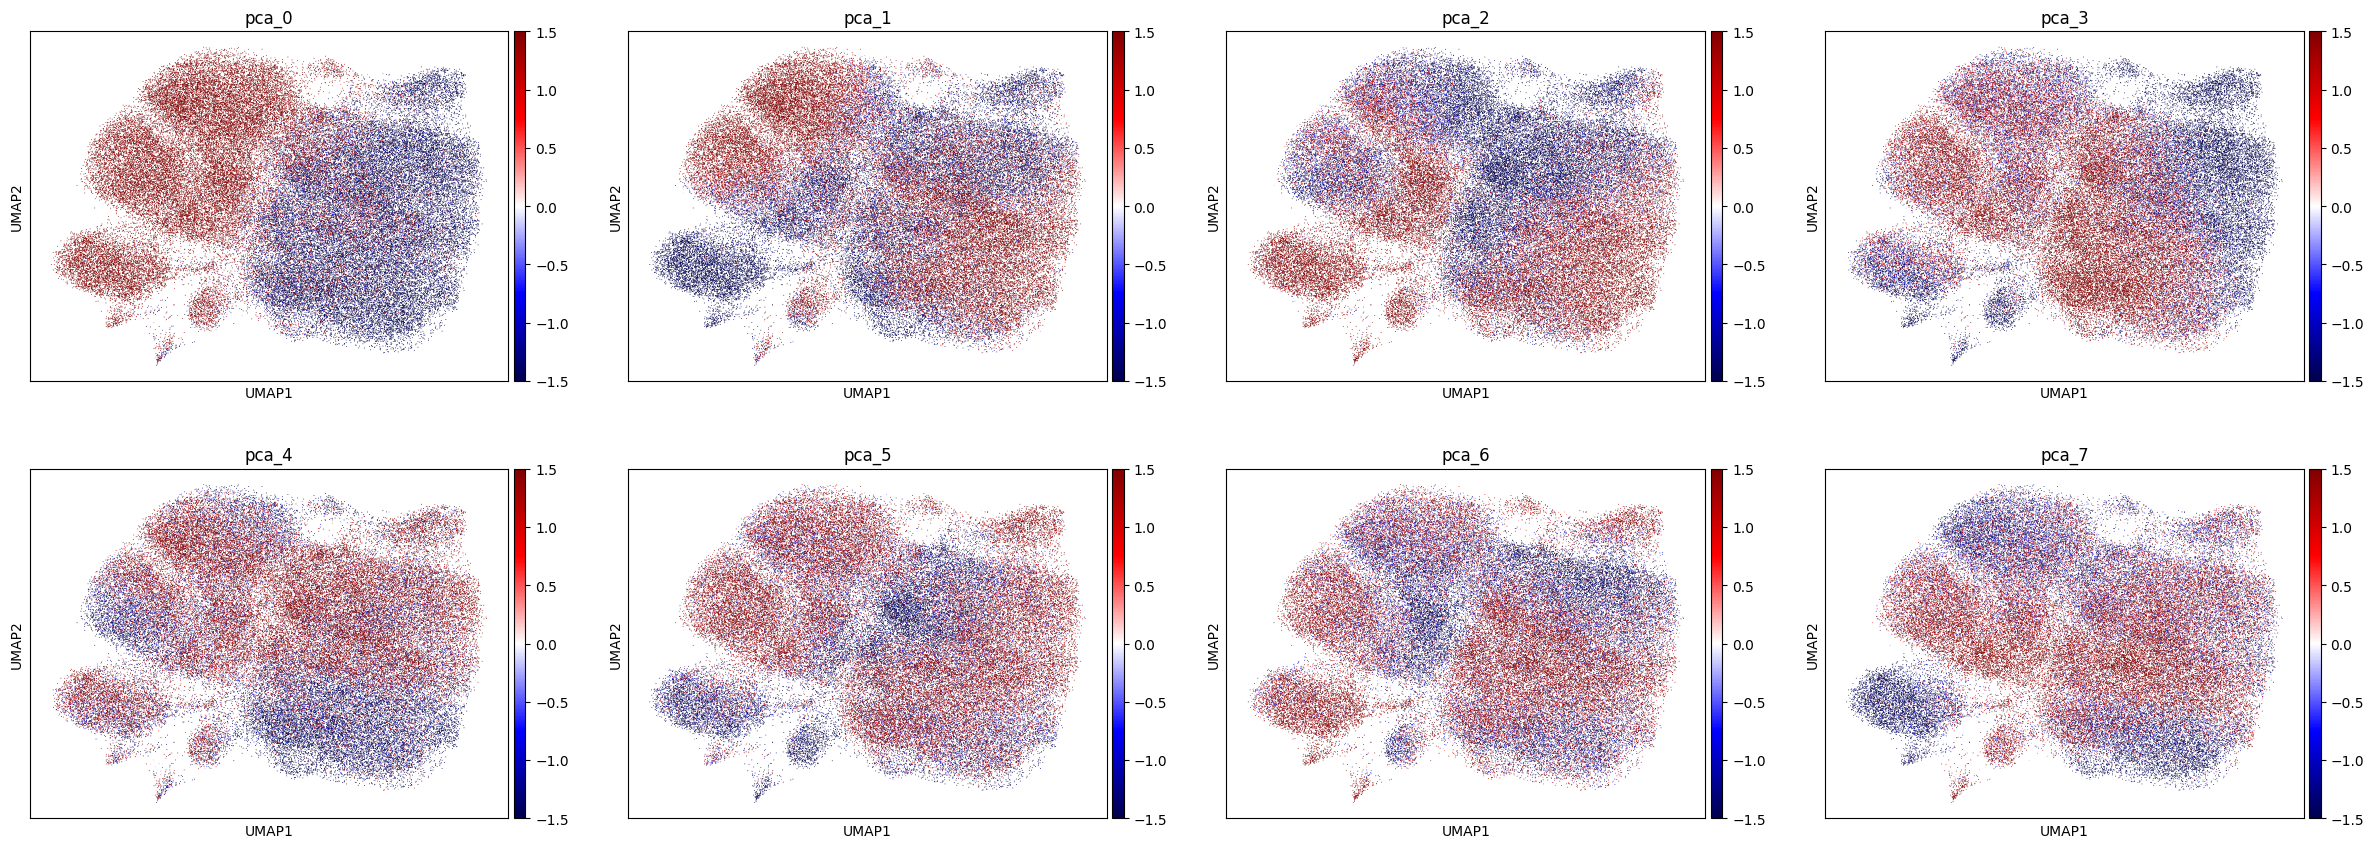

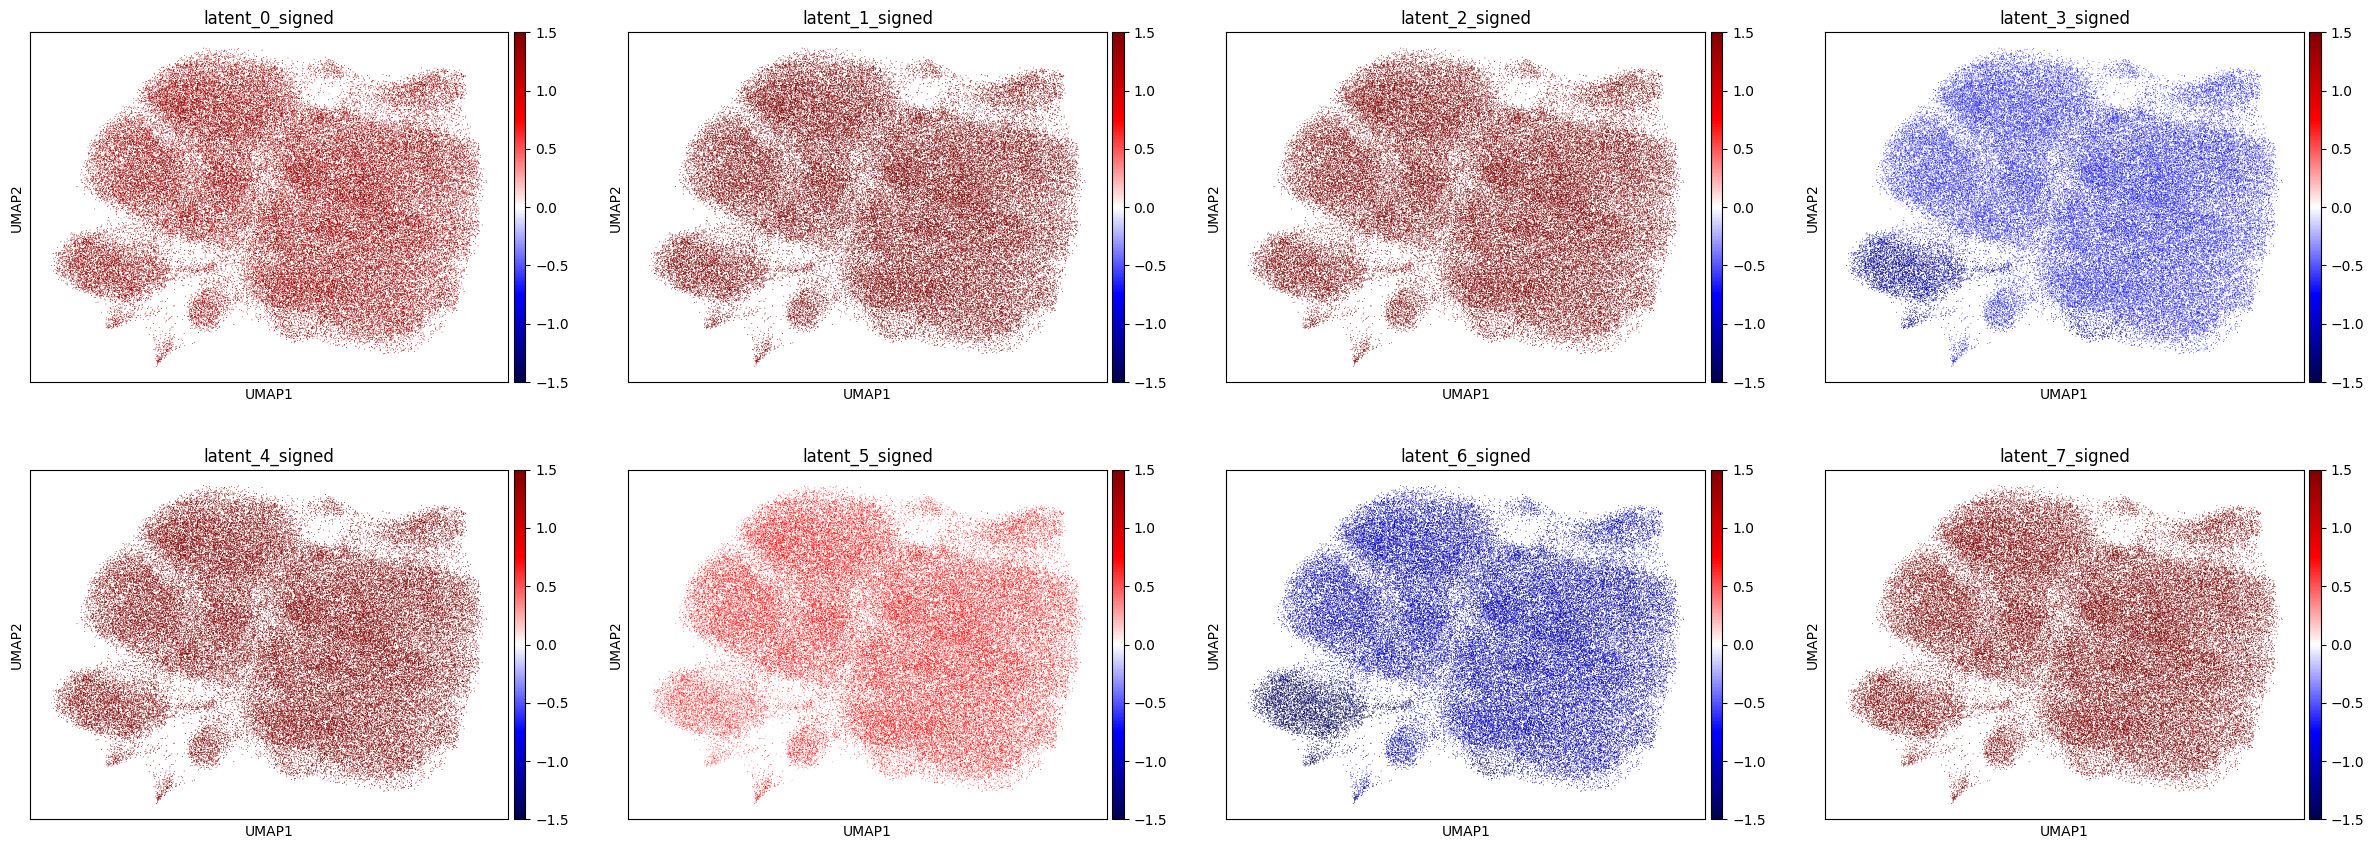

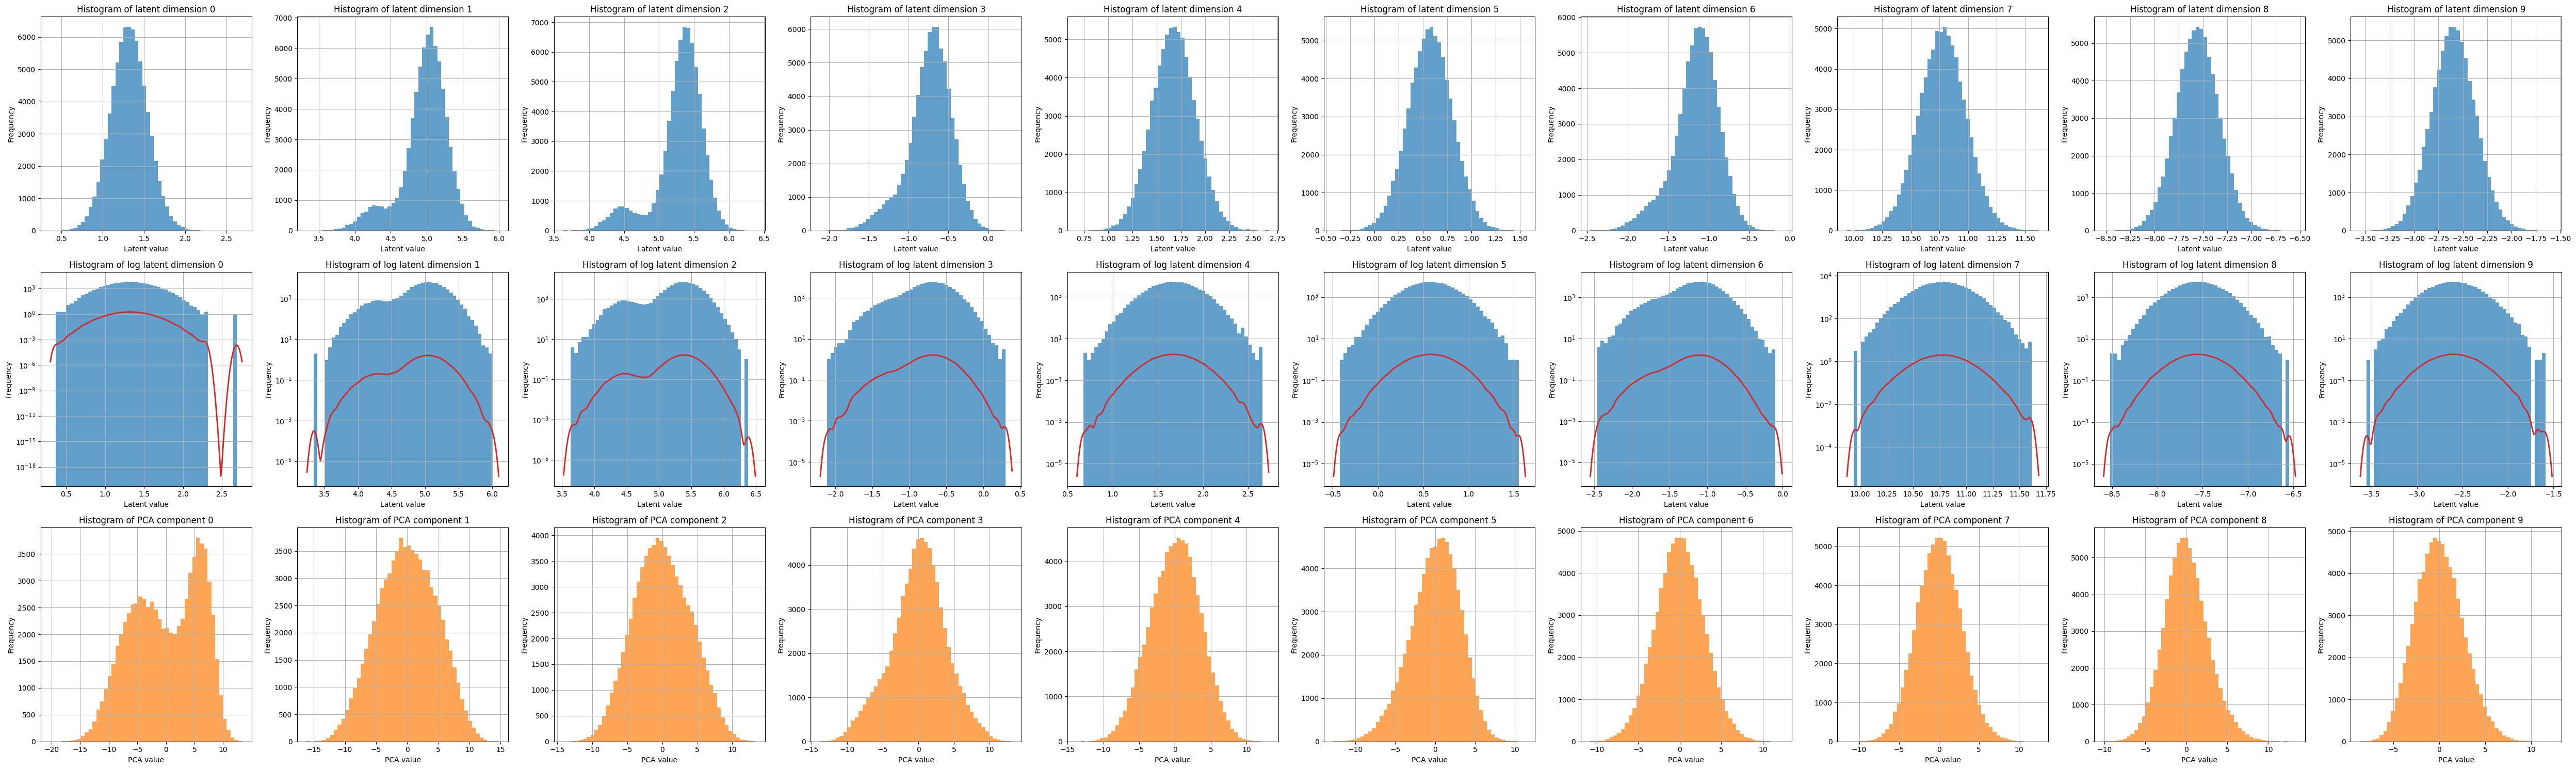

/home/jhoefer/sandbox/src/analysis/plotting.py:335: RuntimeWarning: divide by zero encountered in divide


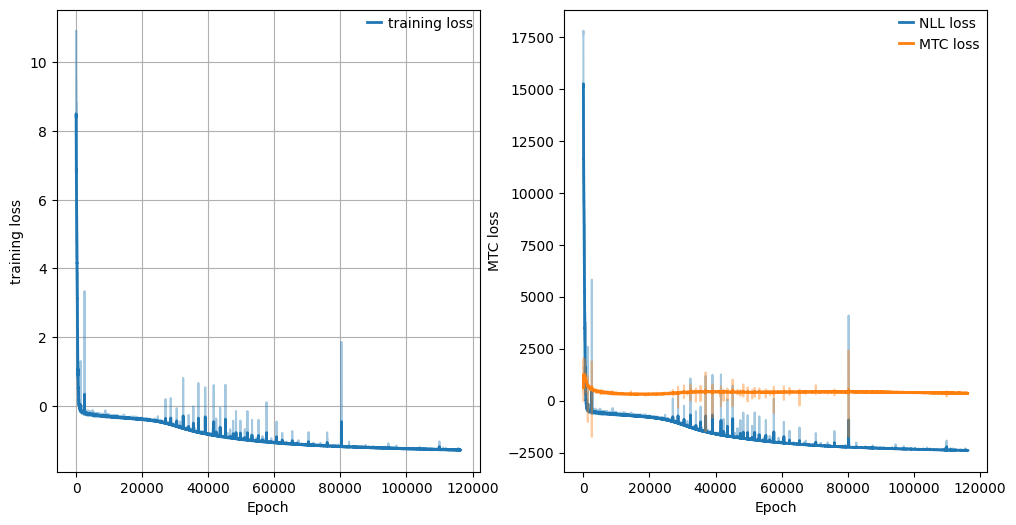

In [33]:
analyze_result(
    analyzer,
    log_scale=False,
    n_latent_factors=8,
    vmax=1.5,
    computation_batch_size=1024,
    analyze_conditions=False,
    use_noise=True,
    latent_dims=latent_dims,
)

### 9.8 Counterfactuals

In [ ]:
results = []
for i in range(3):
    df_counterfactual = compute_counterfactual_distances(
        flow, adata, device=device, dim_to_flip=latent_sort[i]
    )
    df_counterfactual.columns.name = "Flipped Dim " + str(latent_sort[i].item())
    results.append(df_counterfactual)
    display(df_counterfactual)

In [ ]:
if os.path.exists(os.path.join(csv_dir, "counterfactual_edistances.csv")):
    df = pd.read_csv(
        os.path.join(csv_dir, "counterfactual_edistances.csv"), index_col=0
    )
else:
    stim_cfs = []
    ctrl_cfs = []
    for i, df_counterfactual in enumerate(results):
        stim_cfs.append(df_counterfactual["stim"]["stim_cf"])
        ctrl_cfs.append(df_counterfactual["ctrl"]["ctrl_cf"])

    row_names = ["Latent Dim " + str(latent_sort[i].item()) for i in range(3)]
    df = pd.DataFrame({"stim_cfs": stim_cfs, "ctrl_cfs": ctrl_cfs}, index=row_names)
    df.to_csv(os.path.join(csv_dir, "counterfactual_edistances.csv"))

df.style.background_gradient(cmap="coolwarm", axis=None, vmin=-10, vmax=10).format(
    "{:.3f}"
)

### 9.9 Correlations with covariates

In [34]:
if analyzer.latent_sort is None:
    analyzer.compute_jacobian()

correlations = compute_correlations(
    analyzer, n_latents=model_config.latent_per_condition*11 + 3, label_keys=[f"{labels_key}"], dims=np.arange(model_config.latent_per_condition*11 + 3)
)

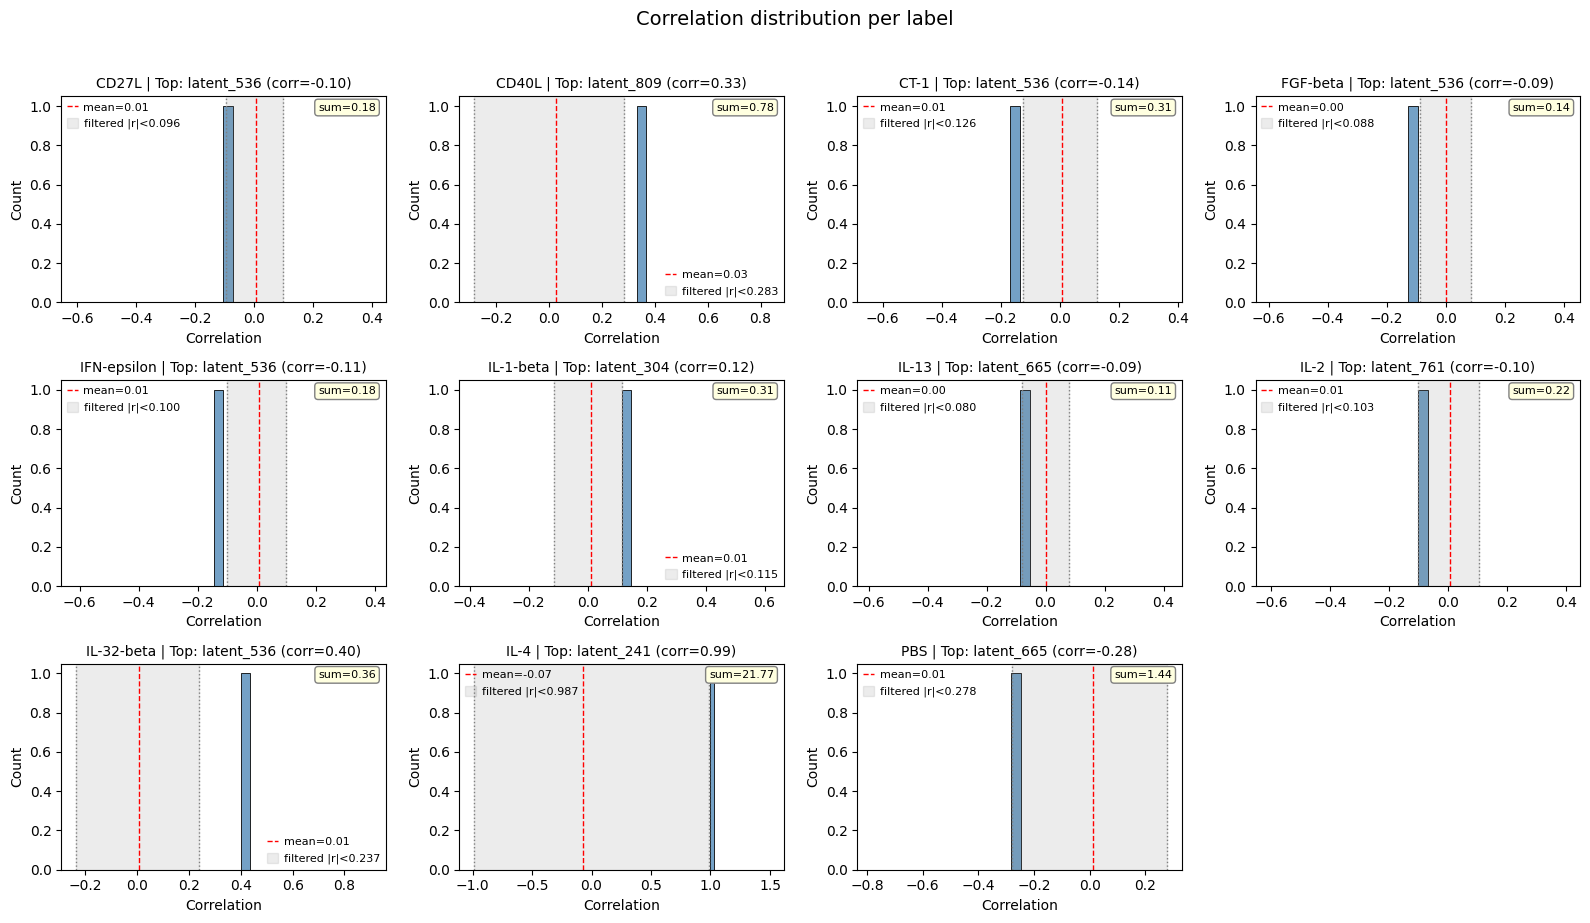

In [35]:
plot_correlation_distribution(correlations, analyzer.latent_sort)

In [36]:
print(dataset.cats[0].categories)
print(analyzer.latent_sort[np.arange(model_config.latent_per_condition*11)])

Index(['CD27L', 'CD40L', 'CT-1', 'FGF-beta', 'IFN-epsilon', 'IL-1-beta',
       'IL-13', 'IL-2', 'IL-32-beta', 'IL-4', 'PBS'],
      dtype='object')
tensor([ 461,   93,  786, 1458, 1653, 1051, 1255,  643,  371,  463,  245, 1698,
         584,  214,  689,  317,  581, 1321, 1348,  464, 1175,  640,  326, 1708,
         284,  945,  920, 1775,  376,  275, 1681,  638,  952,  361,  965,  293,
        1337,  918,  352, 1330,  988, 1474,   77,  475,   99,  142, 1444, 1599,
        1268,  431, 1397,  575,  167,  715, 1627])


In [37]:
df = pd.DataFrame(
    {
        latent: dict(values)  # convert list of tuples to dict for each latent
        for latent, values in correlations.items()
    }
)
df.to_csv(os.path.join(csv_dir, "correlations.csv"))
df.style.background_gradient(cmap="coolwarm", axis=None, vmin=-1, vmax=1).format(
    "{:.3f}"
)

,latent_0,latent_1,latent_2,latent_3,latent_4,latent_5,latent_6,latent_7,latent_8,latent_9,latent_10,latent_11,latent_12,latent_13,latent_14,latent_15,latent_16,latent_17,latent_18,latent_19,latent_20,latent_21,latent_22,latent_23,latent_24,latent_25,latent_26,latent_27,latent_28,latent_29,latent_30,latent_31,latent_32,latent_33,latent_34,latent_35,latent_36,latent_37,latent_38,latent_39,latent_40,latent_41,latent_42,latent_43,latent_44,latent_45,latent_46,latent_47,latent_48,latent_49,latent_50,latent_51,latent_52,latent_53,latent_54,latent_55,latent_56,latent_57
CD27L,-0.021,0.085,0.087,0.091,-0.004,0.062,0.083,0.009,-0.050,-0.046,-0.086,-0.022,0.041,0.013,-0.015,0.004,-0.065,0.085,-0.062,-0.072,0.086,0.038,-0.015,-0.064,-0.045,0.033,0.067,-0.077,-0.068,0.015,-0.017,-0.087,0.077,-0.047,-0.036,0.081,0.037,0.042,-0.016,0.020,-0.017,-0.006,0.061,0.045,-0.104,-0.085,-0.009,0.067,0.053,-0.006,0.008,0.078,0.080,0.003,0.066,0.002,-0.017,0.007
CD40L,-0.007,0.060,0.072,0.074,0.007,0.056,0.053,0.003,-0.055,0.005,-0.062,0.039,0.104,0.222,0.034,-0.073,0.053,0.096,-0.214,-0.077,0.047,0.040,0.158,-0.008,0.332,0.228,0.232,-0.037,0.216,-0.111,-0.078,-0.063,-0.027,-0.096,0.057,0.074,-0.032,0.020,0.191,-0.196,0.245,-0.159,0.105,-0.010,-0.110,-0.049,-0.073,-0.047,0.109,-0.021,-0.137,0.121,0.046,0.135,0.147,-0.013,-0.013,-0.002
CT-1,-0.050,0.116,0.109,0.100,-0.028,0.065,0.114,-0.057,-0.008,-0.044,-0.113,-0.034,0.082,0.038,-0.028,0.003,-0.082,0.114,-0.098,-0.068,0.119,-0.002,-0.047,-0.052,-0.035,0.056,0.112,-0.109,-0.101,0.018,-0.029,-0.107,0.103,-0.066,-0.072,0.112,0.058,0.043,0.007,0.035,-0.008,-0.037,0.072,0.031,-0.135,-0.114,-0.043,0.078,0.039,0.014,0.032,0.100,0.103,-0.005,0.086,-0.006,-0.007,0.018
FGF-beta,-0.014,0.076,0.073,0.070,-0.006,0.044,0.063,-0.008,-0.002,-0.036,-0.075,-0.015,0.042,0.003,-0.032,0.000,-0.060,0.065,-0.057,-0.049,0.074,0.011,-0.027,-0.042,-0.049,0.029,0.028,-0.062,-0.082,0.008,-0.036,-0.078,0.081,-0.045,-0.062,0.064,0.019,0.038,-0.017,0.051,-0.007,-0.006,0.063,0.029,-0.094,-0.076,-0.016,0.053,0.044,-0.009,0.020,0.067,0.068,-0.018,0.064,-0.008,0.001,0.001
IFN-epsilon,-0.023,0.089,0.087,0.088,-0.007,0.049,0.089,-0.023,-0.030,-0.043,-0.090,-0.016,0.055,0.024,-0.027,0.016,-0.054,0.088,-0.077,-0.063,0.089,0.015,-0.014,-0.051,-0.016,0.055,0.071,-0.080,-0.072,0.008,-0.028,-0.087,0.071,-0.047,-0.041,0.084,0.038,0.042,-0.001,0.020,-0.011,-0.015,0.070,0.027,-0.113,-0.084,-0.018,0.063,0.048,0.001,0.013,0.083,0.081,-0.006,0.075,-0.008,-0.015,0.010
IL-1-beta,-0.032,0.101,0.103,0.115,0.023,0.084,0.104,0.060,-0.069,-0.084,-0.109,-0.003,0.037,-0.008,0.010,-0.011,-0.115,0.098,-0.051,-0.100,0.097,0.048,0.004,-0.106,-0.106,0.028,0.073,-0.081,-0.096,0.040,-0.022,-0.109,0.079,-0.073,-0.046,0.101,0.053,0.081,-0.025,0.049,-0.003,0.011,0.079,0.073,-0.106,-0.099,-0.001,0.096,0.088,-0.027,0.037,0.093,0.106,0.018,0.082,0.035,0.029,-0.020
IL-13,-0.015,0.068,0.067,0.059,-0.010,0.020,0.066,-0.040,-0.005,-0.035,-0.069,-0.029,0.040,0.011,-0.016,0.016,-0.046,0.063,-0.043,-0.043,0.072,0.010,-0.035,-0.047,-0.041,0.031,0.045,-0.058,-0.088,-0.001,-0.015,-0.065,0.071,-0.040,-0.051,0.060,0.030,0.022,-0.008,0.046,-0.018,-0.025,0.046,0.033,-0.074,-0.061,-0.019,0.055,0.033,0.008,0.028,0.052,0.062,-0.020,0.042,0.005,-0.014,0.002
IL-2,-0.047,0.090,0.097,0.087,0.020,0.046,0.086,0.015,-0.043,-0.080,-0.096,-0.009,0.044,-0.003,0.004,-0.025,-0.104,0.088,-0.058,-0.069,0.089,0.030,-0.019,-0.088,-0.091,-0.001,0.050,-0.072,-0.103,0.028,-0.029,-0.094,0.084,-0.055,-0.049,0.085,0.040,0.061,-0.008,0.052,0.012,-0.001,0.064,0.071,-0.089,-0.093,-0.009,0.092,0.066,-0.015,0.044,0.071,0.087,0.010,0.052,0.040,0.022,-0.006
IL-32-beta,-0.047,0.067,0.061,0.063,0.049,0.052,0.081,0.010,-0.037,-0.071,-0.080,-0.024,0.018,-0.002,-0.043,0.023,-0.060,0.078,-0.059,-0.081,0.075,0.013,-0.030,-0.016,0.028,0.056,0.042,-0.086,-0.111,-0.067,-0.060,-0.085,0.016,-0.081,-0.110,0.108,0.041,0.006,0.050,-0.025,-0.064,0.017,0.090,0.011,0.402,-0.089,0.039,0.033,0.044,0.035,0.040,0.091,0.085,-0.087,0.017,-

### 9.10 Correlations of dims

In [38]:
if analyzer.latent_sort is None:
    analyzer.compute_jacobian()

max_dim = min(100, kwargs_data["N_dim"])
MPMI_flow = get_MPMI(
    analyzer,
    max_dim=max_dim,
    dtype=torch.float64,
    device="cpu",
    take_mean=False,
)  # [:,latent_sort_gt_polygon]

MPMI_flow = MPMI_flow + MPMI_flow.transpose(1, 2)

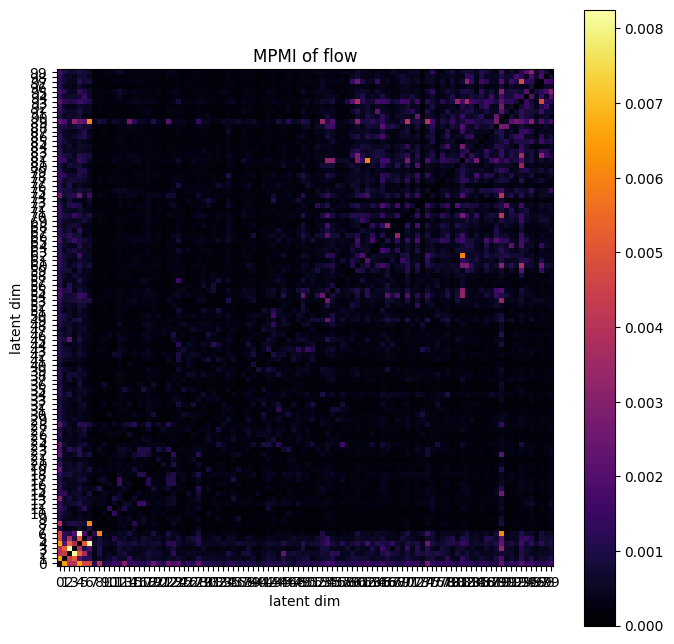

In [39]:
plot_MPMI(
    MPMI_flow.mean(0).numpy(),
    z_max=max_dim,
    title=f"MPMI of flow",
    dim_label="latent dim",
    figsize=8,
)  # , vmin=0, vmax=0.1)

### 9.11 Clusters

In [ ]:
plot_encoded_means_pca(analyzer)

In [ ]:
print(analyzer.model.means[0].shape)

In [ ]:
def plot_latent_means_umap(analyzer, umap_2d=None):
    dataset = analyzer.kwargs_data["dataset"]
    labels = dataset.cats[0].categories.tolist()  # product state labels for means

    # reorder means to match label ordering from dataset
    cat = dataset.cats[0]
    label_to_code = {label: code for code, label in enumerate(cat.categories)}
    ordered_codes = [label_to_code[l] for l in labels]
    means = analyzer.model.means.detach().cpu().numpy()
    means = means[ordered_codes]

    latent_adata = create_latent_adata(analyzer.adata, analyzer.model, analyzer.device)
    Z = latent_adata.X

    if umap_2d is None:
        Z_combined = np.vstack([Z, means])
        combined_adata = ad.AnnData(X=Z_combined.astype("float32"))
        sc.pp.neighbors(combined_adata)
        sc.tl.umap(combined_adata, random_state=42)
        combined_2d = combined_adata.obsm["X_umap"]
    else:
        combined_2d = umap_2d

    Z_2d = combined_2d[: len(Z)]
    means_2d = combined_2d[len(Z) :]

    cat_names = ["product"] + analyzer.conditions

    for cat, name in zip(dataset.cats, cat_names):
        cell_labels = np.array(cat)
        unique_labels = sorted(set(cell_labels))

        cmap = plt.cm.get_cmap("tab20", len(unique_labels))
        color_map = {label: cmap(i) for i, label in enumerate(unique_labels)}

        fig, ax = plt.subplots(figsize=(10, 8))

        for label in unique_labels:
            mask = cell_labels == label
            ax.scatter(
                *Z_2d[mask].T,
                s=5,
                alpha=0.1,
                color=color_map[label],
                label=label,
                rasterized=True,
            )

        if name == "product":
            mean_colors = [color_map.get(l, "black") for l in labels]
        else:
            key_idx = analyzer.conditions.index(name)
            mean_marginal = [l.split("__")[key_idx] for l in labels]
            mean_colors = [color_map.get(l, "black") for l in mean_marginal]

        ax.scatter(
            *means_2d.T,
            s=150,
            c=mean_colors,
            edgecolors="black",
            linewidths=1.5,
            zorder=5,
            marker="*",
        )
        for i, label in enumerate(labels):
            ax.annotate(
                label,
                means_2d[i],
                fontsize=7,
                ha="center",
                va="bottom",
                xytext=(0, 8),
                textcoords="offset points",
            )

        ax.set_title(f"Latent space UMAP — colored by {name}")
        legend = ax.legend(
            markerscale=3,
            bbox_to_anchor=(1.05, 1),
            loc="upper left",
            fontsize=7,
            ncol=max(1, len(unique_labels) // 25),
        )
        for handle in legend.legend_handles:
            handle.set_alpha(1.0)
        plt.tight_layout()
        plt.savefig(
            os.path.join(analyzer.plot_dir, f"latent_means_umap_{name}.png"),
            dpi=300,
            bbox_inches="tight",
        )
        plt.show()

In [ ]:
plot_latent_means_umap(analyzer)

In [ ]:
print(adata.obs[f"{labels_key}"].value_counts())
print(adata.obs[f"cell_type"].value_counts())

In [ ]:
dataset.cats[0].categories.tolist()

In [ ]:
from matplotlib.colors import LogNorm


def plot_pairwise_distances(analyzer, metric="euclidean", log_scale=False, order=None):
    means = analyzer.model.means_active.detach().cpu().numpy()  # (K, D)
    dataset = analyzer.kwargs_data["dataset"]
    labels = dataset.cats[0].categories.tolist()

    if order is not None:
        order = [
            "IL-4__CD4 Memory",
            "IL-32-beta__CD4 Memory",
            "IL-1-beta__CD4 Memory",
            "IL-2__CD4 Memory",
            "CD40L__CD4 Memory",
            "CT-1__CD4 Memory",
            "IFN-epsilon__CD4 Memory",
            "IL-13__CD4 Memory",
            "CD27L__CD4 Memory",
            "FGF-beta__CD4 Memory",
            "PBS__CD4 Memory",
        ]
        order = [
            "IL-4",
            "IL-32-beta",
            "IL-1-beta",
            "IL-2",
            "CD40L",
            "CT-1",
            "IFN-epsilon",
            "IL-13",
            "CD27L",
            "FGF-beta",
            "PBS",
        ]
        idx = [labels.index(l) for l in order]
    else:
        idx = list(range(len(labels)))

    # Pairwise Euclidean distances
    dist_matrix = squareform(pdist(means, metric=metric))
    dist_matrix = dist_matrix[np.ix_(idx, idx)]

    labels = [labels[i] for i in idx]

    # Plot
    fig, ax = plt.subplots(figsize=(8, 7))

    if log_scale:
        im = ax.imshow(
            dist_matrix,
            cmap="viridis",
            norm=LogNorm(
                vmin=dist_matrix[dist_matrix > 0].min(), vmax=dist_matrix.max()
            ),
        )
        log_mid = np.sqrt(dist_matrix[dist_matrix > 0].min() * dist_matrix.max())
        max_val = log_mid
    else:
        im = ax.imshow(dist_matrix, cmap="viridis")
        max_val = dist_matrix.max() * 0.5

    ax.set_xticks(range(len(labels)))
    ax.set_yticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=9)
    ax.set_yticklabels(labels, fontsize=9)

    # Annotate cells
    for i in range(len(labels)):
        for j in range(len(labels)):
            val = dist_matrix[i, j]
            ax.text(
                j,
                i,
                f"{val:.2f}",
                ha="center",
                va="center",
                fontsize=7,
                color="white" if val > max_val else "black",
            )

    if log_scale:
        plt.colorbar(im, ax=ax, label="Distance", format="%.1f")
    else:
        plt.colorbar(im, ax=ax, label="Distance")
    ax.set_title("Pairwise distances")
    plt.tight_layout()
    plt.savefig(
        os.path.join(analyzer.plot_dir, "pairwise_distances.png"),
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()

In [ ]:
print(analyzer.model.means.shape)
print(analyzer.model.means_active.shape)
print(squareform(pdist(analyzer.model.means_active.detach().cpu().numpy(), metric="cosine")))

In [ ]:
plot_pairwise_distances(analyzer, order=1)

In [ ]:
from src.model.data_utils import (
    create_latent_adata,
)


def comapare_learned_vs_empirical_means(analyzer):
    latent_adata = create_latent_adata(analyzer.adata, analyzer.model, analyzer.device)

    empirical_means = []

    dataset = analyzer.kwargs_data["dataset"]
    perturbations = list(dataset.cats[0].categories)

    for key in perturbations:
        mask = analyzer.adata.obs[f"{analyzer.labels_key}"] == key
        empirical_means.append(latent_adata[mask].X.mean(axis=0))

    empirical_means = np.array(empirical_means)

    with torch.no_grad():
        learned_means = analyzer.model.means.cpu().numpy()

    return empirical_means, learned_means


def plot_learned_vs_empirical_means(empirical_means, learned_means, analyzer):

    dataset = analyzer.kwargs_data["dataset"]
    perturbations = list(dataset.cats[0].categories)

    n = len(perturbations)
    combined = np.concatenate([empirical_means, learned_means], axis=0)

    pca = PCA(n_components=2)
    combined_2d = pca.fit_transform(combined)
    empirical_2d = combined_2d[:n]
    learned_2d = combined_2d[n:]

    fig, ax = plt.subplots(figsize=(8, 6))
    cmap = plt.get_cmap("tab10" if n <= 10 else "tab20")

    for i, label in enumerate(perturbations):
        color = cmap(i % cmap.N)
        ax.scatter(*empirical_2d[i], color=color, marker="o", s=80)
        ax.scatter(*learned_2d[i], color=color, marker="x", s=100)
        ax.annotate(label, empirical_2d[i], fontsize=8, alpha=0.8)

    # Legend explaining marker shapes (not per-perturbation, just style)
    ax.scatter([], [], color="black", marker="o", label="Empirical mean")
    ax.scatter([], [], color="black", marker="x", label="Learned mean")
    ax.legend(loc="best", fontsize=8)
    ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%})")
    ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%})")
    ax.set_title("Empirical vs. learned perturbation means (PCA)")
    fig.tight_layout()
    plt.savefig(
        os.path.join(analyzer.plot_dir, "empirical_vs_learned_means.png"), dpi=300
    )
    plt.show()

In [ ]:
emp_means, learned_means = comapare_learned_vs_empirical_means(analyzer)
plot_learned_vs_empirical_means(emp_means, learned_means, analyzer)

In [ ]:
def plot_means_correlation(analyzer):
    means = analyzer.model.means.detach().cpu().numpy()  # (K, N_dim)
    dataset = analyzer.kwargs_data["dataset"]
    labels = dataset.cats[0].categories.tolist()

    corr = np.corrcoef(means)  # (K, K)

    fig, ax = plt.subplots(figsize=(10, 9))
    im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)

    ax.set_xticks(range(len(labels)))
    ax.set_yticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=8)
    ax.set_yticklabels(labels, fontsize=8)

    for i in range(len(labels)):
        for j in range(len(labels)):
            ax.text(
                j,
                i,
                f"{corr[i, j]:.2f}",
                ha="center",
                va="center",
                fontsize=6,
                color="black" if abs(corr[i, j]) < 0.7 else "white",
            )

    plt.colorbar(im, ax=ax, label="Pearson correlation")
    ax.set_title("Correlation matrix of latent means")
    plt.tight_layout()
    plt.savefig(
        os.path.join(analyzer.plot_dir, "means_correlation.png"),
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()

In [ ]:
plot_means_correlation(analyzer)

### 9.12 Counterfactuals

#### 9.12.1 UMAP

In [ ]:
key = "IL-4"

In [ ]:
def generate_counterfactuals(analyzer, key):
    dataset, dataloader = prepare_data(analyzer.adata, batchsize=1024, device=analyzer.device, dtype=analyzer.dtype, label_key=analyzer.conditions, shuffle=False)

    cats = dataset.cats[0].categories.tolist()
    key_idx = cats.index(key)

    means = analyzer.model.means.detach()
    key_mean = means[key_idx].to(device=analyzer.device, dtype=analyzer.dtype)

    all_x_cf = []
    all_z_cf = []
    all_source_labels = []

    with torch.no_grad():
        for x_batch, c_batch in dataloader:
            x_batch = x_batch.to(device=analyzer.device, dtype=analyzer.dtype)
            c_batch = [
                cond.to(device=analyzer.device, dtype=analyzer.dtype)
                for cond in c_batch
            ]

            z_batch, _ = analyzer.model(x_batch, rev=False)

            # source label per cell
            source_idx = torch.argmax(c_batch[0], dim=1)  # (B,)
            keep_mask = source_idx != key_idx
            if not keep_mask.any():
                continue

            z_batch = z_batch[keep_mask]
            source_idx = source_idx[keep_mask]

            source_labels = [cats[i] for i in source_idx.cpu().tolist()]

            current_mean = means[source_idx]  # (B, D)
            mean_shift = key_mean - current_mean

            z_cf = z_batch + mean_shift
            x_cf, _ = analyzer.model(z_cf, rev=True)

            all_x_cf.append(x_cf.cpu())
            all_z_cf.append(z_cf.cpu())
            all_source_labels.extend(source_labels)

    all_x_cf = torch.cat(all_x_cf, dim=0)
    all_z_cf = torch.cat(all_z_cf, dim=0)

    return all_x_cf, all_z_cf, all_source_labels, key

In [ ]:
def plot_cfs_umap(analyzer, x_cf, all_source_labels, key):
    adata_real = analyzer.adata[analyzer.adata.obs[analyzer.labels_key] == key].copy()
    adata_real.obs["group"] = adata_real.obs[analyzer.labels_key]
    adata_real.obs["origin"] = "real"

    adata_cf = analyzer.adata[analyzer.adata.obs[analyzer.labels_key] != key].copy()
    adata_cf.X = x_cf.numpy()

    adata_cf.obs["group"] = [label + "_cf" for label in all_source_labels]
    adata_cf.obs["target"] = key
    adata_cf.obs["origin"] = "counterfactual"

    adata = ad.concat([adata_real, adata_cf])

    sc.pp.pca(adata)
    sc.pp.neighbors(adata)
    sc.tl.umap(adata)

    sc.pl.umap(adata, color=["origin", "group"])
    plt.savefig(
        os.path.join(analyzer.plot_dir, f"counterfactuals_umap_{key}.png"), dpi=300
    )
    plt.show()

In [ ]:
print(analyzer.plot_dir)

In [ ]:
x_cfs, z_cfs, all_source_labels, key_mean = generate_counterfactuals(analyzer, key=key)
plot_cfs_umap(analyzer, x_cfs, all_source_labels, key=key)

#### 9.12.2 MMD

In [ ]:
def gaussian_kernel(x, y, sigma=1.0):
    dist = torch.cdist(x, y)
    return torch.exp(-dist**2 / (2 * sigma**2))
 
def mmd(x, y, kernel=gaussian_kernel, sigma=1.0):
    n_x = x.size(0)
    n_y = y.size(0)
 
    xx = kernel(x, x, sigma=sigma)
    yy = kernel(y, y, sigma=sigma)
    xy = kernel(x, y, sigma=sigma)
 
    term_1 = torch.sum(xx) / (n_x * n_x)
    term_2 = torch.sum(yy) / (n_y * n_y)
    term_3 = 2 * torch.sum(xy) / (n_x * n_y)
 
    return term_1 + term_2 - term_3

In [ ]:
def ctrl_mmd_dists(analyzer, key, iter=10):
    x = analyzer.adata[analyzer.adata.obs[analyzer.labels_key] == key].copy()
    x = x.X.toarray()

    sigma = torch.median(torch.cdist(torch.tensor(x, dtype=torch.float32), torch.tensor(x, dtype=torch.float32)))

    ctrl_mmd = 0.0
    for _ in range(iter):
        n = x.shape[0]
        perm = np.random.permutation(n)

        half = n // 2
        idx1 = perm[:half]
        idx2 = perm[half:]

        x1 = x[idx1]
        x2 = x[idx2]

        x1 = torch.tensor(x1, dtype=torch.float32)
        x2 = torch.tensor(x2, dtype=torch.float32)

        ctrl_mmd += mmd(x1, x2, sigma=sigma)

    ctrl_mmd /= iter

    return ctrl_mmd.item()

In [ ]:
def mmd_dists(analyzer, key, sigma=1.0):
    x_cfs, z_cfs, all_source_labels, key_mean = generate_counterfactuals(
        analyzer, key=key
    )
    all_source_labels = np.array(all_source_labels)

    adata_real = analyzer.adata[analyzer.adata.obs[analyzer.labels_key] == key].copy()
    x_real = torch.tensor(adata_real.X.toarray())

    x_cfs = x_cfs.to("cpu")
    x_real = x_real.to("cpu")

    sigma = torch.median(torch.cdist(x_real, x_real))

    mmd_value = mmd(x_real, x_cfs, sigma=sigma)

    keys = analyzer.adata.obs[analyzer.labels_key].unique()
    mmd_per_group = {}

    for k in tqdm(keys):
        mask = all_source_labels == k
        x_group = x_cfs[mask]
        if len(x_group) > 0:
            x_group = x_group
            mmd_group = mmd(x_real, x_group, sigma=sigma)
            mmd_per_group[k] = mmd_group.item()

    return mmd_value.item(), mmd_per_group

In [ ]:
def plot_mmd_dists(ctrl_mmd, global_mmd, mmd_per_group, key):
    # sort by MMD value
    items = sorted(mmd_per_group.items(), key=lambda x: x[1], reverse=True)

    labels = [k for k, _ in items]
    values = [v for _, v in items]

    plt.figure(figsize=(10, 5))

    plt.bar(labels, values)

    plt.axhline(
        global_mmd,
        color="red",
        linestyle="--",
        linewidth=2,
        label=f"Global MMD ({key})",
    )

    plt.axhline(
        ctrl_mmd,
        color="blue",
        linestyle="--",
        linewidth=2,
        label=f"Control MMD (random split)",
    )

    plt.xticks(rotation=45, ha="right")
    plt.ylabel("MMD")
    plt.title(f"MMD: Counterfactual vs Real ({key})")
    plt.legend()

    plt.tight_layout()
    plt.savefig(
        os.path.join(analyzer.plot_dir, f"mmd_counterfactuals_{key}.png"), dpi=300
    )
    plt.show()

In [ ]:
key = "IL-2"

ctrl_mmd = ctrl_mmd_dists(analyzer, key=key)
print(f"Control MMD (random split): {ctrl_mmd:.4f}")
global_mmd, mmd_per_group = mmd_dists(analyzer, key=key, sigma=1.0)
print(f"Global MMD for {key}: {global_mmd}")

In [ ]:
plot_mmd_dists(ctrl_mmd, global_mmd, mmd_per_group, key=key)

In [ ]:
# cfs_mean = torch.cat(z_cfs, dim=0).mean(dim=0)
# print("Mean of counterfactual latent representations:", cfs_mean)
# print("Mean of original latent representations:", key_mean)

#### 9.12.3 Classify gene space

In [ ]:
def init_classifier(analyzer, binary_key=None, latent=False, hidden_dim = None, labels_key = None):

    if labels_key is None:
        labels_key = analyzer.labels_key

    if latent:
        adata_train = create_latent_adata(
            analyzer.adata,
            analyzer.model,
            analyzer.device,
            analyzer.conditions,
            analyzer.condition_type,
        )
    else:
        adata_train = analyzer.adata.copy()

    if binary_key is not None:
        adata_train.obs[f"{labels_key}"] = adata_train.obs[
            f"{labels_key}"
        ].apply(lambda x: f"{key}" if x == f"{key}" else "rest")

    train_dataset, train_dataloader, test_dataset, test_dataloader = (
        prepare_train_test_data(
            adata_train,
            batchsize=128,
            device=analyzer.device,
            dtype=analyzer.dtype,
            label_key=[f"{labels_key}"],
            test_size=0.2,
        )
    )

    input_dim = adata_train.X.shape[1]
    num_classes = len(adata_train.obs[f"{labels_key}"].unique())

    classifier = LogisticRegressionClassifier(
        input_dim=input_dim, num_classes=num_classes, hidden_dim=hidden_dim
    ).to(analyzer.device)

    return classifier, train_dataloader, test_dataloader, train_dataset, adata_train, num_classes

def evaluate_training_error(adata_train, labels_key, num_classes, class_accuracies):

    if labels_key is None:
        labels_key = analyzer.labels_key

    keys = adata_train.obs[f"{labels_key}"].value_counts().index.tolist()
    df = pd.DataFrame(
        {
            "Class": [f"{keys[i]}" for i in range(num_classes)],
            "Accuracy": class_accuracies,
        }
    )
    df.style.background_gradient(cmap="viridis", subset=["Accuracy"]).format(
        {"Accuracy": "{:.2f}"}
    )

    display(df)

def evaluate_cfs_classification(analyzer, classifier, key, train_dataset, latent=False, labels_key = None):

    if labels_key is None:
        labels_key = analyzer.labels_key

    x_cfs, z_cfs, all_source_labels, key_mean = generate_counterfactuals(analyzer, key=key)
    adata_cf = analyzer.adata[analyzer.adata.obs[analyzer.labels_key] != key].copy()

    if latent:
        adata_cf.X = z_cfs.numpy()
    else:
        adata_cf.X = x_cfs.numpy()

    cf_dataset = AdataDataset(
        adata_cf,
        label_key=None,
        device=analyzer.device,
        dtype=analyzer.dtype,
    )

    cf_loader = DataLoader(
        cf_dataset,
        batch_size=256,
        shuffle=False,
    )

    cats = train_dataset.cats[0].categories.tolist()
    target_idx = cats.index(key)

    classifier.eval()

    predictions = []
    probabilities = []

    with torch.no_grad():
        for x, _ in cf_loader:
            x = x.to(analyzer.device)

            logits = classifier(x)
            probs = torch.softmax(logits, dim=1)

            predictions.append(torch.argmax(probs, dim=1).cpu())
            probabilities.append(probs.cpu())

    predictions = torch.cat(predictions)
    probabilities = torch.cat(probabilities)


    results = []

    source_labels = np.asarray(all_source_labels)

    for source in np.unique(source_labels):
        mask = source_labels == source

        frac = (predictions[mask] == target_idx).float().mean().item()
        mean_prob = probabilities[mask, target_idx].mean().item()

        results.append(
            {
                "source": source,
                "fraction_predicted_target": frac,
                "mean_target_probability": mean_prob,
                "n_cells": int(mask.sum()),
            }
        )

    results = pd.DataFrame(results).sort_values(
        "fraction_predicted_target", ascending=False
    )

    print(results)

    return x_cfs, z_cfs, all_source_labels, target_idx

In [ ]:
classifier, train_dataloader, test_dataloader, train_dataset, adata_train, num_classes = init_classifier(analyzer, binary_key=key)

accuracies, train_loss, val_loss, class_accuracies = train_classifier(
    classifier, train_dataloader, test_dataloader, None, analyzer.device, num_epochs=10
)

In [ ]:
evaluate_training_error(adata_train, analyzer.labels_key, num_classes, class_accuracies)

In [ ]:
evaluate_cfs_classification(analyzer, classifier, key, train_dataset)

#### 9.12.4 Classify latent space

In [ ]:
key = "IL-4"

In [ ]:
latent_classifier, latent_train_dataloader, latent_test_dataloader, latent_train_dataset, latent_adata_train, latent_num_classes = init_classifier(analyzer, latent=True, hidden_dim = None)

latent_accuracies, latent_train_loss, latent_val_loss, latent_class_accuracies = train_classifier(
    latent_classifier, latent_train_dataloader, latent_test_dataloader, None, analyzer.device, num_epochs=10
)

In [ ]:
evaluate_training_error(latent_adata_train, analyzer.labels_key, latent_num_classes, latent_class_accuracies)

In [ ]:
print(adata.obs[analyzer.labels_key].value_counts())

In [ ]:
x_cfs, z_cfs, all_source_labels, target_idx = evaluate_cfs_classification(analyzer, latent_classifier, key, latent_train_dataset, latent=True)

In [ ]:
X_background = []
for x, _ in latent_train_dataloader:
    X_background.append(x)
    if len(X_background) * x.shape[0] >= 500:  # 500 background samples is enough
        break
X_background = torch.cat(X_background, dim=0)[:500].to(analyzer.device)

def model_fn(x):
    latent_classifier.eval()
    with torch.no_grad():
        logits = latent_classifier(torch.tensor(x, dtype=analyzer.dtype, device=analyzer.device))
        return torch.softmax(logits, dim=1).cpu().numpy()
    
# for true logistic regression only
explainer = shap.LinearExplainer(
    (latent_classifier.model.weight.detach().cpu().numpy(),
     latent_classifier.model.bias.detach().cpu().numpy()),
    X_background.cpu().numpy(),
    feature_perturbation="interventional",

)

X_explain = z_cfs.numpy()  # or any latent data you want to explain

shap_values = explainer(X_explain)

In [ ]:
shap_target = shap_values[:,:, target_idx]  # focus on target class
shap.plots.beeswarm(shap_target, max_display=35)

#### 9.12.5 ROC

In [ ]:
key = "PBS"

In [ ]:
x_cfs, z_cfs, all_source_labels, key_mean = generate_counterfactuals(analyzer, key=key)

adata_real = analyzer.adata[analyzer.adata.obs[analyzer.labels_key] == key].copy()
adata_real.obs["origin"] = "original"

adata_cf = analyzer.adata[analyzer.adata.obs[analyzer.labels_key] != key].copy()
adata_cf.X = x_cfs.numpy()
adata_cf.obs["origin"] = "cfs"
adata_cf.obs["source"] = all_source_labels  # keep track of where each cf came from

adata_combined = ad.concat([adata_real, adata_cf])

analyzer_cfs = copy.deepcopy(analyzer)
analyzer_cfs.adata = adata_combined

num_original = adata_real.shape[0]
num_cfs = adata_cf.shape[0]

weights = torch.tensor(
    [1.0 / num_cfs, 1.0 / num_original],
    dtype=torch.float32,
    device=device,
)

weights = weights / weights.sum() * len(weights)

In [ ]:
cfs_classifier, cfs_train_dataloader, cfs_test_dataloader, cfs_train_dataset, cfs_adata_train, cfs_num_classes = init_classifier(analyzer_cfs, latent=False, hidden_dim = None, labels_key="origin")

cfs_accuracies, cfs_train_loss, cfs_val_loss, cfs_class_accuracies = train_classifier(
    cfs_classifier, cfs_train_dataloader, cfs_test_dataloader, weights, analyzer_cfs.device, num_epochs=10
)

In [ ]:
evaluate_training_error(cfs_adata_train, "origin", cfs_num_classes, cfs_class_accuracies)

In [ ]:
cats = cfs_train_dataset.cats[0].categories.tolist()
target_idx = cats.index("original")

In [ ]:
cfs_classifier.eval()
all_probs = []
all_labels = []

with torch.no_grad():
    for x, y in cfs_test_dataloader:
        x = x.to(analyzer.device)
        logits = cfs_classifier(x)
        probs = torch.softmax(logits, dim=1)
        all_probs.append(probs.cpu().numpy())
        all_labels.append(y[0].argmax(dim=1).cpu().numpy())  # one-hot to int

all_probs = np.concatenate(all_probs, axis=0)
all_labels = np.concatenate(all_labels, axis=0)

# for binary classifier: use probability of positive class
fpr, tpr, _ = roc_curve(all_labels, all_probs[:, target_idx])
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, color="steelblue", lw=2, label=f"ROC curve (AUC = {roc_auc:.3f})")
ax.plot([0, 1], [0, 1], color="gray", lw=1, linestyle="--", label="Random")
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")
ax.set_title(f"ROC curve {key} - counterfactuals vs original")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(analyzer.plot_dir, f"roc_curve_{key}.png"), dpi=300)
plt.show()

print(f"AUC: {roc_auc:.3f}")

## 10. Ablation Studies

### 10.1 Paths

In [ ]:
USE_METACELLS = False

dataset_name = "parse"
top_genes = 2000
cell_types = ["CD4 Memory"]

if adata is None or not check_adata_params(
    adata, dataset_name, top_genes, cell_types=cell_types
):
    adata, labels_key, control_label = load_data(
        dataset_name,
        top_genes,
        log_transform=True,
        cell_types=cell_types,
    )

if USE_METACELLS:
    adata, labels_key, control_label = load_data(
        dataset_name,
        top_genes,
        log_transform=True,
        cell_types=cell_types,
    )
    adata = build_metacells(adata, group_keys=["cell_type", f"{labels_key}"])

N_dim = adata.X.shape[1]
D_dim = N_dim

load_scvi(adata, dataset_name, N_dim)

In [ ]:
model_dir_name = f"/g/stegle/jhoefer/models/EOFlow/{dataset_name}/top_{N_dim}"
output_dir_path = f"/home/jhoefer/sandbox/results/{dataset_name}/top_{N_dim}"

postfix = "_best"
ablation_dir = model_dir_name + postfix
ablation_output_dir = output_dir_path + postfix

losses = None

### 10.2 Losses

In [ ]:
if losses is None:
    losses = get_losses_ablation(ablation_dir, [3], device)

In [ ]:
keys = losses.keys()
print(keys)
# keys = sorted(keys, key=lambda x: float(x))

colors = plt.cm.viridis(np.linspace(0, 1, len(keys)))

fig, ax = plt.subplots(figsize=(10, 5))
for i, key in enumerate(keys):
    plot_loss(losses[key], f"{key}", filter_lim=3, filter_N=50, color=colors[i], ax=ax)
plt.xlabel("Updates")
plt.ylabel("Loss")
plt.title("Losses for different LRs")
plt.tight_layout()
plt.savefig(os.path.join(ablation_output_dir, "plots", "MTC_losses.png"))
plt.show()

In [ ]:
epoch_losses = {}
for i, key in enumerate(losses.keys()):
    N_batches = np.ceil(adata.X.shape[0] / 1024).astype(int)
    epoch_losses[key] = losses[key].reshape(-1, N_batches).mean(axis=1)

keys = epoch_losses.keys()
# keys = sorted(keys, key=lambda x: float(x))

colors = plt.cm.viridis(np.linspace(0, 1, len(keys)))

fig, ax = plt.subplots(figsize=(10, 5))
for i, key in enumerate(keys):
    plot_loss(
        epoch_losses[key], f"{key}", filter_lim=3, filter_N=50, color=colors[i], ax=ax
    )
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Losses for different batch sizes")
plt.tight_layout()
plt.savefig(os.path.join(ablation_output_dir, "plots", "MTC_epoch_losses.png"))
plt.show()

### 10.3 Minimum Losses for Hyperparams

In [ ]:
if losses is None:
    losses = get_losses_ablation(ablation_dir, [0], device)

In [ ]:
noise_levels = sorted(losses.keys(), key=lambda x: float(x))
lam_MTCs = losses[noise_levels[0]].keys()

min_losses = {}
for sigma in noise_levels:
    min_losses[sigma] = []
    for lam_MTC in losses[sigma].keys():
        min_losses[sigma].append(min(losses[sigma][lam_MTC]))

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))
for sigma in noise_levels:
    lam_values = [float(lam) for lam in losses[sigma].keys()]
    ax.plot(
        lam_values,
        min_losses[sigma],
        marker="o",
        label=f"Noise={sigma}",
    )
ax.set_title("Transformed - Minimum Loss across Lambda MTC")
ax.set_xlabel("Lambda MTC")
ax.set_ylabel("Minimum Loss")
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(output_dir_path, "plots", "min_loss_comparison.png"))

### 10.4 Ablation Plots & spectra

In [ ]:
umaps = True
correlations = True
MPMI = True
conditions = [f"{labels_key}"]

sigma_noises = [0.4]
lam_MTCs = [0.1]
prefix = "6_"

H_is_ablation = {}
latent_sorts_ablation = {}

for sigma_noise in sigma_noises:

    if sigma_noise not in H_is_ablation:
        H_is_ablation[sigma_noise] = {}
        latent_sorts_ablation[sigma_noise] = {}

    for lam_MTC in lam_MTCs:
        H_i, latent_sort = analyze_model(
            adata,
            dataset_name,
            labels_key,
            control_label,
            lam_MTC,
            sigma_noise,
            device,
            dtype,
            prefix=prefix,
            folder_postfix=postfix,
            conditions=conditions,
            batch_size=1024,
            umaps=umaps,
            correlations=correlations,
            MPMI=MPMI,
        )
        H_is_ablation[sigma_noise][lam_MTC] = H_i
        latent_sorts_ablation[sigma_noise][lam_MTC] = latent_sort

### 10.5 Spectra Ablation

In [ ]:
print(sorted(H_is_ablation.keys()))

In [ ]:
noise_levels = sorted(H_is_ablation.keys())
fig, ax = plt.subplots(
    len(noise_levels) // 2 + len(noise_levels) % 2,
    2,
    figsize=(20, 6 * len(noise_levels) // 2),
)

for i, sigma in enumerate(noise_levels):
    lambda_MTCs = list(H_is_ablation[sigma].keys())
    plot_ME_spectrum(
        list(H_is_ablation[sigma].values()),
        latent_sort=list(latent_sorts_ablation[sigma].values()),
        title=f"Noise: {float(sigma)}",
        sigma_noise=float(sigma),
        names=lambda_MTCs,
        plot_dir=os.path.join(
            output_dir_path, "plots", f"ME_spectrum_noise_{sigma}.png"
        ),
        log_scale=False,
        ax=ax[i // 2][i % 2],
    )

    pca, _ = calculate_pca(adata, float(sigma))
    plot_PCA_spectrum(
        pca.explained_variance_,
        log_scale=False,
        sigma_noise=float(sigma),
        names=["PCA"],
        ax=ax[i // 2][i % 2],
    )
    ax[i // 2][i % 2].set_title(f"Noise: {float(sigma)}")

plt.savefig(os.path.join(output_dir_path, "plots", "ME_spectra_comparison_Noise.png"))
plt.show()

In [ ]:
H_is_ablation_reverse = reverse_dict(H_is_ablation)
latent_sorts_ablation_reverse = reverse_dict(latent_sorts_ablation)

lam_MTCs = sorted(H_is_ablation_reverse.keys())
fig, ax = plt.subplots(
    len(lam_MTCs) // 2 + len(lam_MTCs) % 2, 2, figsize=(20, 6 * len(lam_MTCs) // 2)
)

for i, lam_ in enumerate(lam_MTCs):
    sigma = list(H_is_ablation_reverse[lam_].keys())
    plot_ME_spectrum(
        list(H_is_ablation_reverse[lam_].values()),
        latent_sort=list(latent_sorts_ablation_reverse[lam_].values()),
        title=f"Lam_MTC: {float(lam_)}",
        names=sigma,
        log_scale=False,
        ax=ax[i // 2][i % 2],
    )
plt.savefig(os.path.join(output_dir_path, "plots", "ME_spectra_comparison_Lam.png"))
plt.show()

### 10.6 Show Correlations

In [ ]:
output_dir_path = "/home/jhoefer/sandbox/results/parse/top_1779/csv"
path = f"{output_dir_path}"
for dir in os.listdir(path):
    full_path = os.path.join(path, dir)
    for file in os.listdir(full_path):
        file_path = os.path.join(full_path, file)
        print(file_path)
        display_csv(file_path)

### 10.7 Clusters

In [ ]:
conditions = [f"{labels_key}"]

for model in os.listdir(ablation_dir):
    prefix_model = model.split("_")[0] + "_" + model.split("_")[1]

    lam_MTC = float(model.split("_")[3])
    sigma_noise = float(model.split("_")[5])
    prefix_model = prefix_model + "_"

    print(f"Analyzing model with prefix: {prefix_model}")
    print(f"Model path: {os.path.join(ablation_dir, model)}")
    analyzer = Analyzer.from_checkpoint(
        adata,
        dataset_name,
        labels_key,
        control_label,
        lam_MTC,
        sigma_noise,
        prefix=prefix_model,
        folder_postfix=postfix,
        conditions=conditions,
        device=device,
        dtype=dtype,
        test_size=0.0,
    )

    # plot_encoded_means_pca(analyzer)
    # plot_latent_means_umap(analyzer)
    # plot_pairwise_distances(analyzer)
    analyze_result(analyzer, log_scale = False, use_noise = True)

    # key = "PBS"

    # x_cfs, z_cfs, all_source_labels, key_mean = generate_counterfactuals(analyzer, key=key)

    # adata_real = analyzer.adata[analyzer.adata.obs[analyzer.labels_key] == key].copy()
    # adata_real.obs["origin"] = "original"

    # adata_cf = analyzer.adata[analyzer.adata.obs[analyzer.labels_key] != key].copy()
    # adata_cf.X = x_cfs.numpy()
    # adata_cf.obs["origin"] = "cfs"
    # adata_cf.obs["source"] = all_source_labels  # keep track of where each cf came from

    # adata_combined = ad.concat([adata_real, adata_cf])

    # analyzer_cfs = copy.deepcopy(analyzer)
    # analyzer_cfs.adata = adata_combined

    # num_original = adata_real.shape[0]
    # num_cfs = adata_cf.shape[0]

    # weights = torch.tensor(
    #     [1.0 / num_cfs, 1.0 / num_original],
    #     dtype=torch.float32,
    #     device=device,
    # )

    # weights = weights / weights.sum() * len(weights)

    # cfs_classifier, cfs_train_dataloader, cfs_test_dataloader, cfs_train_dataset, cfs_adata_train, cfs_num_classes = init_classifier(analyzer_cfs, latent=False, hidden_dim = None, labels_key="origin")

    # cfs_accuracies, cfs_train_loss, cfs_val_loss, cfs_class_accuracies = train_classifier(
    #     cfs_classifier, cfs_train_dataloader, cfs_test_dataloader, weights, analyzer_cfs.device, num_epochs=10
    # )

    # cats = cfs_train_dataset.cats[0].categories.tolist()
    # target_idx = cats.index("original")

    # cfs_classifier.eval()
    # all_probs = []
    # all_labels = []

    # with torch.no_grad():
    #     for x, y in cfs_test_dataloader:
    #         x = x.to(analyzer.device)
    #         logits = cfs_classifier(x)
    #         probs = torch.softmax(logits, dim=1)
    #         all_probs.append(probs.cpu().numpy())
    #         all_labels.append(y[0].argmax(dim=1).cpu().numpy())  # one-hot to int

    # all_probs = np.concatenate(all_probs, axis=0)
    # all_labels = np.concatenate(all_labels, axis=0)

    # # for binary classifier: use probability of positive class
    # fpr, tpr, _ = roc_curve(all_labels, all_probs[:, target_idx])
    # roc_auc = auc(fpr, tpr)

    # fig, ax = plt.subplots(figsize=(6, 5))
    # ax.plot(fpr, tpr, color="steelblue", lw=2, label=f"ROC curve (AUC = {roc_auc:.3f})")
    # ax.plot([0, 1], [0, 1], color="gray", lw=1, linestyle="--", label="Random")
    # ax.set_xlabel("False positive rate")
    # ax.set_ylabel("True positive rate")
    # ax.set_title(f"ROC curve {key} - counterfactuals vs original")
    # ax.legend(fontsize=9)
    # plt.tight_layout()
    # plt.savefig(os.path.join(analyzer.plot_dir, f"roc_curve_{key}.png"), dpi=300)
    # plt.show()

    # print(f"AUC: {roc_auc:.3f}")

In [ ]:
adata

## 11. Benchmarker

In [ ]:
dataset_name = "parse"
top_genes = 2000
cell_types = ["CD4 Memory"]

if adata is None or not check_adata_params(
    adata, dataset_name, top_genes, cell_types=cell_types
):
    adata, labels_key, control_label = load_data(
        dataset_name,
        top_genes,
        log_transform=True,
        cell_types=cell_types,
    )

N_dim = adata.X.shape[1]
D_dim = N_dim

lam_MTC = 0.1
sigma_noise = 0.7
prefix = "_"
folder_postfix = ""

if analyzer is None or not check_analyzer_params(
    analyzer, dataset_name, lam_MTC, sigma_noise, N_dim, prefix, folder_postfix
):
    analyzer = Analyzer.from_checkpoint(
        adata,
        dataset_name,
        labels_key,
        control_label,
        lam_MTC,
        sigma_noise,
        prefix=prefix,
        folder_postfix=folder_postfix,
    )

In [ ]:
bottlenecks = [5, 50, 100]
representations = {}

for bottleneck_dim in bottlenecks:
    repr, _ = return_bottleneck_representation(
        analyzer=analyzer,
        bottleneck_dim=bottleneck_dim,
    )
    representations[bottleneck_dim] = repr
    adata.obsm["X_bottleneck_" + str(bottleneck_dim)] = repr

In [ ]:
gc.collect()
torch.cuda.empty_cache()

In [ ]:
for key in adata.obsm.keys():
    adata.obsm[key] = adata.obsm[key].astype("float32")
for key in adata.obsp.keys():
    adata.obsp[key] = adata.obsp[key].astype("float32")
adata.X = adata.X.astype("float32")

In [ ]:
bm_cell_type = Benchmarker(
    adata,
    batch_key="patient",
    label_key="cell_type",
    bio_conservation_metrics=BioConservation(),
    batch_correction_metrics=BatchCorrection(),
    embedding_obsm_keys=[
        "X_pca",
        "X_umap",
        "X_scVI",
        "X_bottleneck_5",
        "X_bottleneck_50",
        "X_bottleneck_100",
    ],
    n_jobs=8,
)
bm_cell_type.benchmark()

In [ ]:
bm_condition = Benchmarker(
    adata,
    batch_key="patient",
    label_key="condition",
    bio_conservation_metrics=BioConservation(),
    batch_correction_metrics=BatchCorrection(),
    embedding_obsm_keys=[
        "X_pca",
        "X_umap",
        "X_scVI",
        "X_bottleneck_5",
        "X_bottleneck_50",
        "X_bottleneck_100",
    ],
    n_jobs=8,
)
bm_condition.benchmark()

In [ ]:
bm_cell_type.plot_results_table()
bm_condition.plot_results_table()

## 12. Logistic Regression

In [ ]:
dataset_name = "parse"
top_genes = 2000
cell_types = ["CD4 Memory"]

if adata is None or not check_adata_params(
    adata, dataset_name, top_genes, cell_types=cell_types
):
    adata, labels_key, control_label = load_data(
        dataset_name,
        top_genes,
        log_transform=True,
        cell_types=cell_types,
    )

N_dim = adata.X.shape[1]
D_dim = N_dim

lam_MTC = 0.1
sigma_noise = 0.2
prefix = "5e-4_"
folder_postfix = "_cond_mixture_train_means"

if analyzer is None or not check_analyzer_params(
    analyzer, dataset_name, lam_MTC, sigma_noise, N_dim, prefix, folder_postfix
):
    analyzer = Analyzer.from_checkpoint(
        adata,
        dataset_name,
        labels_key,
        control_label,
        lam_MTC,
        sigma_noise,
        prefix=prefix,
        folder_postfix=folder_postfix,
    )

In [ ]:
latent_adata = create_latent_adata(
    analyzer.adata,
    analyzer.model,
    analyzer.device,
    conditions=analyzer.conditions,
    condition_type=analyzer.condition_type,
)

train_dataset, train_dataloader, test_dataset, test_dataloader = (
    prepare_train_test_data(
        latent_adata,
        batchsize=128,
        device=device,
        dtype=dtype,
        label_key=[f"{labels_key}"],
        test_size=0.2,
    )
)
input_dim = latent_adata.X.shape[1]
num_classes = len(latent_adata.obs[f"{labels_key}"].unique())
print(f"Input dimension: {input_dim}, Number of classes: {num_classes}")

classifier = LogisticRegressionClassifier(
    input_dim=input_dim, num_classes=num_classes, hidden_dim=None
).to(device)
accuracies, train_loss, val_loss, class_accuracies = train_classifier(
    classifier, train_dataloader, test_dataloader, device, num_epochs=100
)

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].plot(accuracies, marker="o")
ax[0].set_title("Validation Accuracy")
ax[0].set_xlabel("Epoch")
ax[0].set_ylabel("Accuracy")
ax[1].plot(train_loss, label="Train Loss", marker="o")
ax[1].plot(val_loss, label="Validation Loss", marker="o")
ax[1].set_title("Loss Curves")
ax[1].set_xlabel("Epoch")
ax[1].set_ylabel("Loss")
ax[1].legend()
plt.tight_layout()

In [ ]:
keys = adata.obs[f"{labels_key}"].value_counts().index.tolist()
df = pd.DataFrame(
    {
        "Class": [f"{keys[i]}" for i in range(num_classes)],
        "Accuracy": class_accuracies,
    }
)
df.style.background_gradient(cmap="viridis", subset=["Accuracy"]).format(
    {"Accuracy": "{:.2f}"}
)

In [ ]:
def classify_counterfactuals(analyzer):
    latent_adata = create_latent_adata(
        analyzer.adata,
        analyzer.model,
        analyzer.device,
        conditions=analyzer.conditions,
        condition_type=analyzer.condition_type,
    )

## 13. Cytokine Effects

In [ ]:
dataset_name = "parse"
top_genes = 2000
cell_types = ["CD4 Memory"]

if adata is None or not check_adata_params(
    adata, dataset_name, top_genes, cell_types=cell_types
):
    adata, labels_key, control_label = load_data(
        dataset_name,
        top_genes,
        log_transform=True,
        cell_types=cell_types,
    )

N_dim = adata.X.shape[1]
D_dim = N_dim

lam_MTC = 0.1
sigma_noise = 0.2
prefix = "5e-4_"
folder_postfix = "_cond_mixture_train_means"
conditions = [f"{labels_key}"]

if analyzer is None or not check_analyzer_params(
    analyzer, dataset_name, lam_MTC, sigma_noise, N_dim, prefix, folder_postfix
):
    analyzer = Analyzer.from_checkpoint(
        adata,
        dataset_name,
        labels_key,
        control_label,
        lam_MTC,
        sigma_noise,
        prefix=prefix,
        folder_postfix=folder_postfix,
        conditions=conditions,
    )

print(analyzer.model.means_active.shape)
if analyzer.jac_dec is None:
    analyzer.compute_jacobian()

In [ ]:
dataset = analyzer.kwargs_data["dataset"]
labels_key = analyzer.labels_key

latent_adata = create_latent_adata(analyzer.adata, analyzer.model, analyzer.device)
Z = latent_adata.X  # (N, D)

combined_adata = ad.AnnData(X=Z.astype("float32"))
sc.pp.neighbors(combined_adata)
sc.tl.umap(combined_adata, random_state=42)

combined_2d = combined_adata.obsm["X_umap"]
Z_2d = combined_2d[: len(Z)]

labels = analyzer.adata.obs[labels_key].values
unique_labels = sorted(set(labels))
palette = dict(zip(unique_labels, plt.cm.tab20.colors[: len(unique_labels)]))

fig, ax = plt.subplots(figsize=(8, 6))
for label in unique_labels:
    mask = labels == label
    ax.scatter(
        *Z_2d[mask].T,
        s=5,
        alpha=0.1,
        label=label,
        color=palette[label],
        rasterized=True
    )

ax.legend(
    markerscale=3,
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    fontsize=8,
    handles=[
        plt.Line2D(
            [0],
            [0],
            marker="o",
            color="w",
            markerfacecolor=palette[l],
            markersize=8,
            label=l,
        )
        for l in unique_labels
    ],
)
plt.tight_layout()
plt.show()

### 13.1 Bottlenecks

In [ ]:
def get_perturbation_dim_importance(analyzer, perturbation, control_label=None, trick = False):
    """
    Rank latent dimensions by their importance for a specific perturbation,
    based on the displacement of the perturbation mean from the control mean.
    """
    if control_label is None:
        control_label = analyzer.control_label

    dataset = analyzer.kwargs_data["dataset"]
    categories = dataset.cats[0].categories.tolist()
    means = analyzer.model.means.detach().cpu()  # (K, N_dim)

    pert_idx = categories.index(perturbation)
    ctrl_idx = categories.index(control_label)
    if trick:
        pert_idx += 1

    pert_mean = means[pert_idx]   # (N_dim,)
    ctrl_mean = means[ctrl_idx]   # (N_dim,)

    # displacement vector: how much does this perturbation shift each dim
    delta = pert_mean - ctrl_mean  # (N_dim,)

    # rank by absolute displacement
    importance = torch.abs(delta)
    dim_order = torch.argsort(importance, descending=True)

    return dim_order.numpy(), delta.numpy()

In [ ]:
RANDOM = False
MEANS = True
pert = "IL-4"
trick = True

In [ ]:
perturbations = adata.obs["cytokine"].unique()
perturbations = [c for c in perturbations if c != control_label]

FULL_DE = False

keep_dims = [N_dim, 1700, 1500, 1000, 750, 500, 250, 100, 75, 50, 25, 10, 5, 3, 0]
vae_bottlenecks = [N_dim, 500, 50, 25, 15, 8, 3, 1]

if RANDOM:
    analyzer.latent_sort = torch.randperm(N_dim)
elif MEANS:
    if pert == None:
        raise ValueError("Please specify a perturbation for MEANS sorting.")
    else:
        perturbations = [pert]
        analyzer.latent_sort, _ = get_perturbation_dim_importance(analyzer, perturbation=pert, control_label=control_label, trick = trick)

vae_bottlenecks = [N_dim]
# keep_dims = [N_dim, 50, 10]
# keep_dims = [N_dim]
# drop_ = [1, 3, 5, 10, 25, 50, 75, 100, 250, 500, 750, 1000, 1500, N_dim]

In [ ]:
(
    rhos,
    direction_agreements,
    top_overlaps,
    lfc_shifts,
    rhos_pca,
    direction_agreements_pca,
    top_overlaps_pca,
    lfc_shifts_pca,
    rhos_vae,
    direction_agreements_vae,
    top_overlaps_vae,
    lfc_shifts_vae,
) = evaluate_de_effects(
    analyzer,
    perturbations,
    keep_dims,
    vae_bottlenecks,
    batch_size=1024,
    use_noise=False,
    FULL_DE=FULL_DE,
)

In [ ]:
metrics = [
    ("Spearman Rho", rhos, rhos_pca, rhos_vae),
    (
        "Direction Agreement",
        direction_agreements,
        direction_agreements_pca,
        direction_agreements_vae,
    ),
    ("Top 100 Overlap", top_overlaps, top_overlaps_pca, top_overlaps_vae),
    ("LFC Shift", lfc_shifts, lfc_shifts_pca, lfc_shifts_vae),
]

colors = [
    f"tab:{c}"
    for c in ["blue", "orange", "green", "red", "purple", "brown", "pink", "gray"]
]

fig, axes = plt.subplots(len(metrics), 3, figsize=(14, 5 * len(metrics)), sharey="row")

for row, (label, flow_vals, pca_vals, vae_vals) in enumerate(metrics):
    for col, (vals, linestyle, tag) in enumerate(
        [
            (flow_vals, "solid", "Flow"),
            (pca_vals, "dashed", "PCA"),
            (vae_vals, "dotted", "VAE"),
        ]
    ):
        if tag == "VAE":
            x = vae_bottlenecks
        else:
            x = keep_dims

        a = axes[row, col]
        for i, pert in enumerate(perturbations):
            a.plot(
                x,
                vals.T[i],
                marker="o",
                color=colors[i % len(colors)],
                linestyle=linestyle,
                label=pert,
            )
        a.set_title(f"{label} — {tag}")
        a.set_xlabel("First n nonzero Latent Dims")
        a.set_ylabel(label)
        # a.set_ylim(0, 1.01)
        a.legend()
        a.grid()

plt.suptitle("DE Result Stability vs. Number of Latent Dims", fontsize=14)
plt.tight_layout()

de = "full" if FULL_DE else "lfc"
postfix = "_means" if MEANS else ""
postfix += "_random" if RANDOM else ""
postfix += "_trick" if trick else ""
name = f"DE_stability_vs_latent_dims_{de}_{postfix}"
plt.savefig(os.path.join(analyzer.plot_dir, f"{name}.png"))
plt.show()

In [ ]:
print(adata.obs[f"{labels_key}"].value_counts())

### 13.2 Learning a rotation

In [ ]:
perturbations = ["IL-4"]
keep_dims = [1000, 500, 250, 100, 50, 25, 10, 5, 3, 1]

perm_module = LearnedSoftPermutation(N_dim).to(device)
perm_optimizer = torch.optim.Adam(perm_module.parameters(), lr=5e-3)

de_dfs, de_sig_dfs = {}, {}
de_dfs_gt, de_sig_dfs_gt = evaluate_de_effects_gt(
    analyzer, perturbations, de_dfs, de_sig_dfs
)
sig_genes = _get_gt_sig_genes(de_sig_dfs_gt, perturbations)
if not FULL_DE:
    de_dfs, de_sig_dfs = {}, {}
    gt_adata = analyzer.adata.copy()
    gt_adata.layers["counts"] = gt_adata.X.copy()
    lfc_results = _get_logfold_changes(
        gt_adata, analyzer.labels_key, analyzer.control_label, sig_genes=sig_genes
    )
    _collect_lfc_results(perturbations, f"original", lfc_results, de_dfs, de_sig_dfs)


latent_adata = create_latent_adata(analyzer.adata, analyzer.model, analyzer.device)
dataset, dataloader = prepare_data(
    latent_adata,
    batchsize=256,
    device=analyzer.device,
    dtype=analyzer.dtype,
    label_key=None,
    shuffle=False,
)


flow_rev = partial(analyzer.model, rev=True)

for epoch in tqdm(range(1)):
    for keep_dim in keep_dims:
        ctrl_sum = None
        pert_sums = {pert: None for pert in perturbations}

        ctrl_count = 0
        pert_counts = {pert: 0 for pert in perturbations}

        ctrl_mask_full = torch.tensor(
            (analyzer.adata.obs[analyzer.labels_key].values == analyzer.control_label),
            dtype=torch.bool,
            device=analyzer.device,
        )
        pert_masks_full = {
            pert: torch.tensor(
                (analyzer.adata.obs[analyzer.labels_key].values == pert),
                dtype=torch.bool,
                device=analyzer.device,
            )
            for pert in perturbations
        }

        offset = 0

        for i_batch, (z_batch, _) in enumerate(dataloader):
            z_batch = z_batch.to(device=analyzer.device, dtype=analyzer.dtype)
            mask = torch.zeros_like(z_batch)
            mask[:, analyzer.latent_sort[:keep_dim]] = 1

            z_perm = perm_module(z_batch)
            z_masked = z_perm * mask

            x_recon, _ = checkpoint(flow_rev, z_masked, use_reentrant=False)

            bsz = z_batch.shape[0]
            ctrl_mask_batch = ctrl_mask_full[offset : offset + bsz]
            if ctrl_mask_batch.any():
                sum = x_recon[ctrl_mask_batch].sum(dim=0)
                ctrl_sum = sum if ctrl_sum is None else ctrl_sum + sum
                ctrl_count += ctrl_mask_batch.sum().item()

            for pert in perturbations:
                pert_mask_batch = pert_masks_full[pert][offset : offset + bsz]
                if pert_mask_batch.any():
                    sum = x_recon[pert_mask_batch].sum(dim=0)
                    pert_sums[pert] = (
                        sum if pert_sums[pert] is None else pert_sums[pert] + sum
                    )
                    pert_counts[pert] += pert_mask_batch.sum().item()

            offset += bsz

            if (i_batch % 20 == 0 or i_batch == len(dataloader) - 1) and i_batch > 0:
                ctrl_mean = (ctrl_sum / ctrl_count).clamp(min=1e-8)
                results = {"var_names": list(analyzer.adata.var_names)}

                for pert in perturbations:
                    pert_mean = (pert_sums[pert] / pert_counts[pert]).clamp(min=1e-8)
                    lfc = torch.log2(pert_mean) - torch.log2(ctrl_mean)

                    if sig_genes is not None and pert in sig_genes:
                        idx = [
                            i
                            for i, g in enumerate(results["var_names"])
                            if g in sig_genes[pert]
                        ]
                        idx = torch.tensor(idx, device=analyzer.device)
                        lfc = lfc[idx]
                        results[f"var_names_{pert}"] = [
                            results["var_names"][i] for i in idx.cpu().tolist()
                        ]

                    results[pert] = lfc

                lfc_shift = differentiable_lfc_results(de_dfs, results, perturbations)
                loss = decay_loss(lfc_shift, keep_dim, N_dim)
                print(f"Keep dim {keep_dim} - Loss: {loss.item():.4f}")
                loss.backward()
                perm_optimizer.step()
                perm_optimizer.zero_grad()

                ctrl_sum = None
                pert_sums = {pert: None for pert in perturbations}

                ctrl_count = 0
                pert_counts = {pert: 0 for pert in perturbations}

    perm_module.temp = max(0.01, 1.0 * 0.95**epoch)

    torch.save(
        {
            "permutation_module": perm_module.state_dict(),
            "optimizer": perm_optimizer.state_dict(),
            "epoch": epoch,
        },
        "/home/jhoefer/sandbox/models/permutations/permutation_checkpoint.pt",
    )

In [ ]:
perturbations = ["IL-4"]

FULL_DE = False
keep_dims = [N_dim, 1500, 1000, 750, 500, 250, 100, 75, 50, 25, 10, 5, 3, 0]

checkpoint = torch.load(
    "/home/jhoefer/sandbox/models/permutations/dim_selector_checkpoint.pt",
    map_location=device,
)

# perm_module = LearnedSoftPermutation(N_dim).to(device)
# perm_module.load_state_dict(checkpoint["dim_selector"])

selector = LearnedDimSelector(N_dim).to(device)
selector.load_state_dict(checkpoint["dim_selector"])

if analyzer.latent_sort is None:
    analyzer.compute_jacobian()

(
    rhos,
    direction_agreements,
    top_overlaps,
    lfc_shifts,
    rhos_rotated,
    direction_agreements_rotated,
    top_overlaps_rotated,
    lfc_shifts_rotated,
) = evaluate_permuted_results(
    analyzer,
    perturbations,
    keep_dims,
    select_module=selector,
    use_noise=False,
    batch_size=1024,
    FULL_DE=FULL_DE,
)

In [ ]:
checkpoint = torch.load(
    "/home/jhoefer/sandbox/models/permutations/permutation_checkpoint.pt",
    map_location=device,
)

perm_module = LearnedSoftPermutation(N_dim).to(device)
perm_module.load_state_dict(checkpoint["permutation_module"])

P = perm_module.get_permutation_matrix()
idx = 7

dims = []
for idx in range(N_dim):
    argmax_dim = P[idx].argmax().item()
    dims.append(argmax_dim)

dims = np.array(dims)
plt.figure(figsize=(10, 6))
plt.hist(dims, bins=np.arange(-0.5, N_dim + 0.5, 1), alpha=0.7, color="blue")

# How binary is P? Close to 0/1 means converged
print(f"Mean max per row: {P.max(dim=1).values.mean():.4f}")  # should be ~1.0
print(
    f"Mean entropy per row: {(-P * (P + 1e-8).log()).sum(dim=1).mean():.4f}"
)  # should be ~0

# Check for collisions
unique_dims = len(np.unique(dims))
print(f"Unique dims assigned: {unique_dims} / {N_dim}")  # should equal N_dim

In [ ]:
metrics = [
    ("Spearman Rho", rhos, rhos_rotated),
    ("Direction Agreement", direction_agreements, direction_agreements_rotated),
    ("Top 100 Overlap", top_overlaps, top_overlaps_rotated),
    ("LFC Shift", lfc_shifts, lfc_shifts_rotated),
]

colors = [
    f"tab:{c}"
    for c in ["blue", "orange", "green", "red", "purple", "brown", "pink", "gray"]
]

fig, axes = plt.subplots(len(metrics), 2, figsize=(14, 5 * len(metrics)), sharey="row")

for row, (label, flow_vals, flow_vals_rotated) in enumerate(metrics):
    for col, (vals, linestyle, tag) in enumerate(
        [
            (flow_vals, "solid", "Flow"),
            (flow_vals_rotated, "dashed", "Flow (Rotated)"),
        ]
    ):
        x = keep_dims
        a = axes[row, col]
        for i, pert in enumerate(perturbations):
            a.plot(
                x,
                vals.T[i],
                marker="o",
                color=colors[i % len(colors)],
                linestyle=linestyle,
                label=pert,
            )
        a.set_title(f"{label} — {tag}")
        a.set_xlabel("First n nonzero Latent Dims")
        a.set_ylabel(label)
        a.legend()
        a.grid()

plt.suptitle("DE Result Stability vs. Number of Latent Dims", fontsize=14)
plt.tight_layout()

de = "full" if FULL_DE else "lfc"
name = f"Rotated_DE_stability_vs_latent_dims_{de}"
plt.savefig(os.path.join(analyzer.plot_dir, f"{name}.png"))
plt.show()

In [ ]:
errs = []
errs_gauss = []

for x_batch, _ in analyzer.kwargs_data["dataloader"]:
    x_batch = x_batch.to(analyzer.device)
    x_batch_gauss = (
        x_batch + torch.randn_like(x_batch) * analyzer.kwargs_data["sigma_noise"]
    )

    with torch.no_grad():
        z_batch, _ = analyzer.model(x_batch, rev=False)
        x_recon, _ = analyzer.model(z_batch, rev=True)

        z_batch_gauss, _ = analyzer.model(x_batch_gauss, rev=False)
        x_recon_gauss, _ = analyzer.model(z_batch_gauss, rev=True)

    errs.append(torch.norm(x_batch - x_recon, dim=1).cpu().numpy())
    errs_gauss.append(torch.norm(x_batch_gauss - x_recon_gauss, dim=1).cpu().numpy())
errs = np.concatenate(errs)
errs_gauss = np.concatenate(errs_gauss)

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.hist(errs, bins=50, color="skyblue", edgecolor="black", density=True)
ax1.set_title("Reconstruction Error Distribution")
ax1.set_xlabel("L2 Reconstruction Error")
ax1.set_ylabel("Frequency")
ax1.set_xlim(0, 0.001)
ax1.grid()

ax2.hist(
    errs_gauss, bins=50, color="lightcoral", edgecolor="black", alpha=0.7, density=True
)
ax2.set_title("Reconstruction Error Distribution (Gaussian Noise)")
ax2.set_xlabel("L2 Reconstruction Error")
ax2.set_ylabel("Frequency")
ax2.set_xlim(0, 0.001)
ax2.grid()